# RetailHero Purchase Uplift Modeling Experiment

## Problem Definition

The RetailHero dataset was released by X5 Retail Group for an uplift-modeling competition on promotional communication.

The business setting is customer targeting for an advertising SMS campaign.

A conventional response model asks:

> Which customers are most likely to make a purchase?

For campaign targeting, however, the more relevant question is:

> Which customers are more likely to make a purchase **because they receive the promotional communication**?

A customer who is already very likely to purchase may receive a high response score even if the campaign does not change their behavior. Uplift modeling instead focuses on the **incremental effect of treatment**.

The objective of this experiment is therefore to compare conventional response-based targeting with uplift-based targeting.

The main decision question is:

> **Under a limited targeting budget, which policy selects customers with the highest incremental purchase outcome?**

The experiment compares:

* **Response Model** as the conventional targeting baseline;
* **T-Learner** as an uplift-model candidate;
* **X-Learner** as an uplift-model candidate.

The goal is not exhaustive hyperparameter optimization. The goal is to compare these modeling approaches under the same prepared data structure, split strategy, validation protocol, and targeting budgets.


## EDA Direction

The EDA focuses on the customers in the **labeled uplift dataset (`uplift_train`)**.

The goal is to understand how these customers behaved **before the campaign**, then check whether different customer patterns are associated with different campaign responses.

> **Which pre-campaign customer patterns may help explain differences in campaign response?**

The useful patterns found here will guide later hypothesis checks and feature engineering.

In [538]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

COLORS = {
    "pacific_green": "#017360",
    "rainy_lake": "#446E8F",
    "serene_sea": "#77A7C4",
    "sora_blue": "#A1DBF1",
    "afterglow": "#F2E6CE",
    "bungalow_maple": "#F3D094",
}

PALETTE = list(COLORS.values())

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize":11,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [539]:
CLEAN_DIR = Path(
    r"d:\thao\d\uplif_model\uplif_customer_selection\data\interim\retailhero\clean"
)

DATA_PATHS = {
    "clients": CLEAN_DIR / "clients_clean.parquet",
    "products": CLEAN_DIR / "products_clean.parquet",
    "purchases": CLEAN_DIR / "purchases_clean.parquet",
    "uplift_train": CLEAN_DIR / "uplift_train_clean.parquet",
}

con = duckdb.connect()

for name, path in DATA_PATHS.items():
    con.execute(
        f"""
        CREATE OR REPLACE VIEW {name} AS
        SELECT *
        FROM read_parquet('{path.as_posix()}')
        """
    )

In [540]:
dataset_overview = []

for name in DATA_PATHS:
    row_count = con.sql(
        f"SELECT COUNT(*) AS n FROM {name}"
    ).fetchone()[0]

    column_count = len(
        con.sql(f"DESCRIBE {name}").df()
    )

    dataset_overview.append({
        "dataset": name,
        "rows": row_count,
        "columns": column_count,
    })

dataset_overview = pd.DataFrame(dataset_overview)

display(dataset_overview)

,dataset,rows,columns
0,clients,400162,5
1,products,43038,11
2,purchases,45786568,13
3,uplift_train,200039,3


The EDA population is the **200,039 customers in `uplift_train`**.  
The other tables are used to add customer profile, purchase history, and product information for these customers.

## Experiment Structure Check

Before starting the EDA, first check the basic treatment-control setup.

This checks:

- One row per customer;
- Valid treatment and target values;
- Treatment and control group sizes;
- Basic pre-campaign balance between the two groups.

This is a balance check, not proof that treatment assignment was randomized.

In [541]:
experiment_check = con.sql(
    """
    SELECT
        COUNT(*) AS rows,
        COUNT(DISTINCT client_id) AS unique_clients,

        SUM(CASE WHEN treatment_flg = 0 THEN 1 ELSE 0 END) AS control,
        SUM(CASE WHEN treatment_flg = 1 THEN 1 ELSE 0 END) AS treatment,

        SUM(CASE WHEN treatment_flg NOT IN (0, 1) OR treatment_flg IS NULL
                 THEN 1 ELSE 0 END) AS invalid_treatment,

        SUM(CASE WHEN target NOT IN (0, 1) OR target IS NULL
                 THEN 1 ELSE 0 END) AS invalid_target
    FROM uplift_train
    """
).df()

display(experiment_check)

,rows,unique_clients,control,treatment,invalid_treatment,invalid_target
0,200039,200039,"100,058.0000","99,981.0000",0.0000,0.0000


In [542]:
treatment_distribution = con.sql(
    """
    SELECT
        treatment_flg,
        COUNT(*) AS customers,
        COUNT(*) * 100.0 / SUM(COUNT(*)) OVER () AS percentage
    FROM uplift_train
    GROUP BY treatment_flg
    ORDER BY treatment_flg
    """
).df()

display(treatment_distribution)

,treatment_flg,customers,percentage
0,0,100058,50.0192
1,1,99981,49.9808


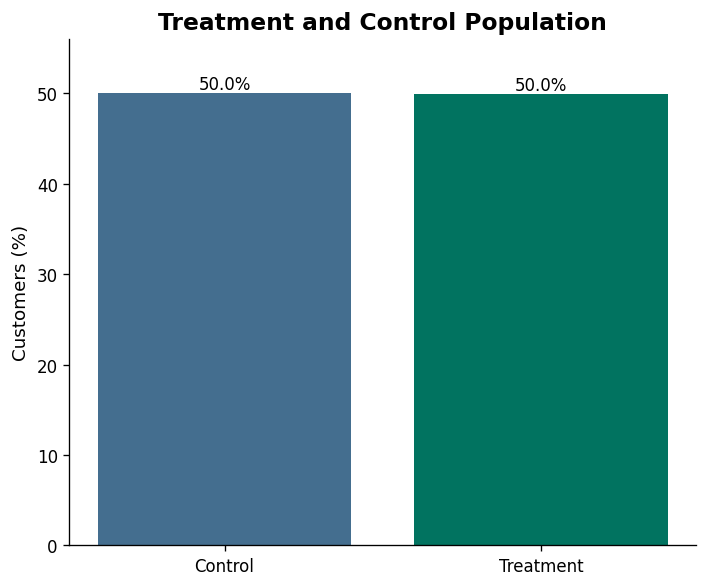

In [543]:
fig, ax = plt.subplots(figsize=(6, 5))

bars = ax.bar(
    ["Control", "Treatment"],
    treatment_distribution["percentage"],
    color=[
        COLORS["rainy_lake"],
        COLORS["pacific_green"],
    ],
)

ax.set_title("Treatment and Control Population")
ax.set_ylabel("Customers (%)")

for bar, value in zip(
    bars,
    treatment_distribution["percentage"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
    )

ax.set_ylim(
    0,
    treatment_distribution["percentage"].max() * 1.12,
)

plt.tight_layout()
plt.show()

In [544]:
experiment_clients = con.sql(
    """
    SELECT
        u.client_id,
        u.treatment_flg,
        u.target,
        c.age,
        c.gender,
        c.first_issue_date,
        c.first_redeem_date
    FROM uplift_train AS u
    LEFT JOIN clients AS c
        USING (client_id)
    """
).df()

In [545]:
age_balance = (
    experiment_clients
    .groupby("treatment_flg")["age"]
    .agg(["count", "mean", "median"])
)

age_balance.index = ["Control", "Treatment"]

display(age_balance)

,count,mean,median
Control,99663,46.3657,45.0000
Treatment,99569,46.4514,45.0000


In [546]:
gender_balance = pd.crosstab(
    experiment_clients["gender"],
    experiment_clients["treatment_flg"],
    normalize="columns",
).mul(100)

gender_balance.columns = ["Control (%)", "Treatment (%)"]

display(gender_balance)

,Control (%),Treatment (%)
gender,,
F,36.7637,36.9180
M,16.7763,16.7282
U,46.4601,46.3538


#### Experiment Structure Findings

- The experiment contains **200,039 unique customers**, with valid treatment and target values.
- Treatment and control are almost evenly split at approximately **50% / 50%**.
- Age and gender distributions are also very similar between the two groups.

The observed experiment structure is therefore reasonably balanced for the following EDA.

## 1. Customer and Purchase Behavior

First, customer population and their historical purchase behavior before treatment.

This includes patterns such as:

* How recently customers purchased;
* How frequently they purchased;
* How much they spent;
* How their purchases were distributed across products and stores;
* Whether customers showed different levels of purchasing activity.

The purpose is to understand what kinds of customer behaviors exist in the dataset before attempting to represent them as model features.

### 1.1 Customer Population

Before examining purchase behavior, first identify the customers included in the uplift experiment and describe their basic characteristics.

In [547]:
customer_population = con.sql(
    """
    SELECT
        u.client_id,
        c.*
        EXCLUDE (client_id)
    FROM uplift_train AS u
    LEFT JOIN clients AS c
        USING (client_id)
    """
).df()

print(f"EDA population: {len(customer_population):,}")
display(customer_population.head())

EDA population: 200,039


,client_id,first_issue_date,first_redeem_date,age,gender
0,ee43c35beb,2017-06-10 11:58:43,2017-12-28 16:25:54,63,M
1,ee43cc9492,2017-08-03 18:54:30,2017-10-13 11:06:27,49,F
2,ee443a393d,2017-07-11 18:20:38,2018-07-15 18:26:28,35,M
3,ee44445b00,2018-03-27 14:34:57,2019-07-15 11:54:13,37,F
4,ee44dc3920,2019-02-28 20:29:14,2019-07-26 21:00:19,36,U


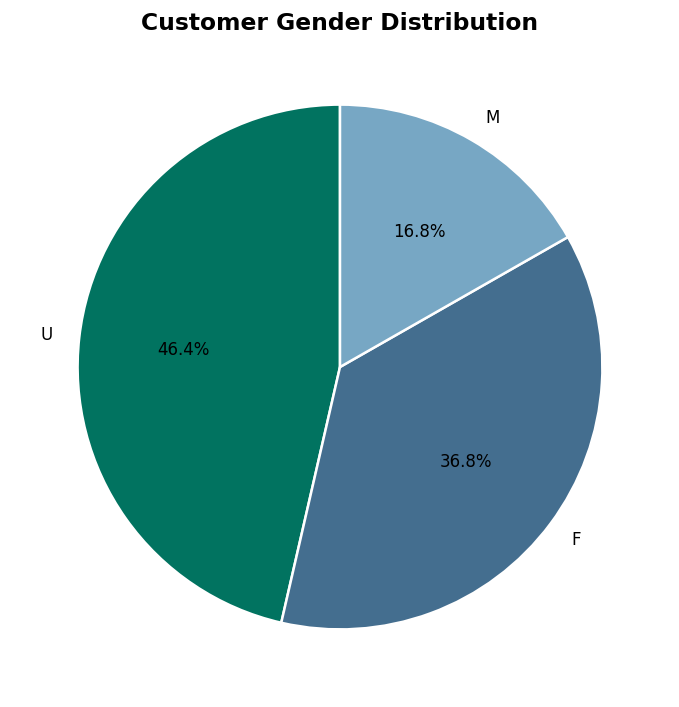

In [548]:
gender_counts = (
    customer_population["gender"]
    .fillna("Unknown")
    .value_counts()
)

gender_pct = gender_counts / gender_counts.sum() * 100

fig, ax = plt.subplots(figsize=(6, 6))

ax.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=PALETTE[:len(gender_counts)],
    wedgeprops={
        "edgecolor": "white",
        "linewidth": 1.5,
    },
)

ax.set_title("Customer Gender Distribution")

plt.tight_layout()
plt.show()


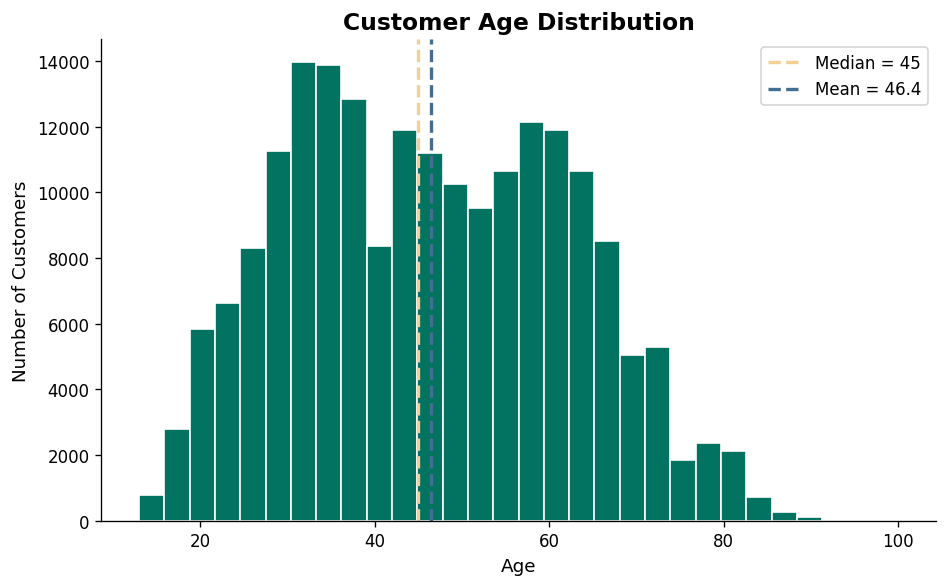

,count,mean,std,min,25%,50%,75%,max
age,"199,232.0000",46.4085,15.8856,13.0000,34.0000,45.0000,59.0000,100.0000


In [549]:
age = customer_population["age"].dropna()

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    age,
    bins=30,
    color=COLORS["pacific_green"],
    edgecolor="white",
)

ax.axvline(
    age.median(),
    color=COLORS["bungalow_maple"],
    linestyle="--",
    linewidth=2,
    label=f"Median = {age.median():.0f}",
)

ax.axvline(
    age.mean(),
    color=COLORS["rainy_lake"],
    linestyle="--",
    linewidth=2,
    label=f"Mean = {age.mean():.1f}",
)

ax.set_title("Customer Age Distribution")
ax.set_xlabel("Age")
ax.set_ylabel("Number of Customers")
ax.legend()

plt.tight_layout()
plt.show()

display(
    customer_population["age"]
    .describe()
    .to_frame("age")
    .T
)

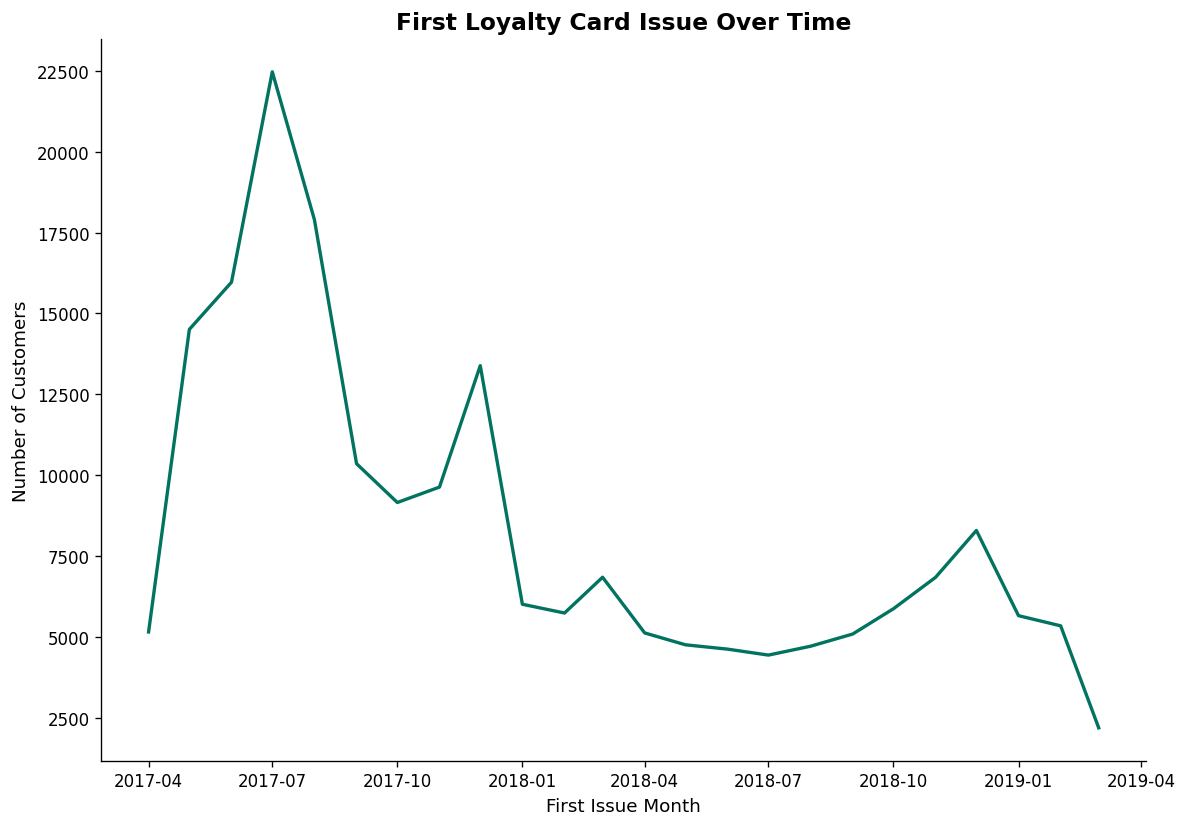

In [550]:
issue_monthly = (
    customer_population
    .assign(
        issue_month=lambda df:
            df["first_issue_date"].dt.to_period("M").dt.to_timestamp()
    )
    .groupby("issue_month")
    .size()
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(
    issue_monthly.index,
    issue_monthly.values,
    color=COLORS["pacific_green"],
    linewidth=2,
)

ax.set_title("First Loyalty Card Issue Over Time")
ax.set_xlabel("First Issue Month")
ax.set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

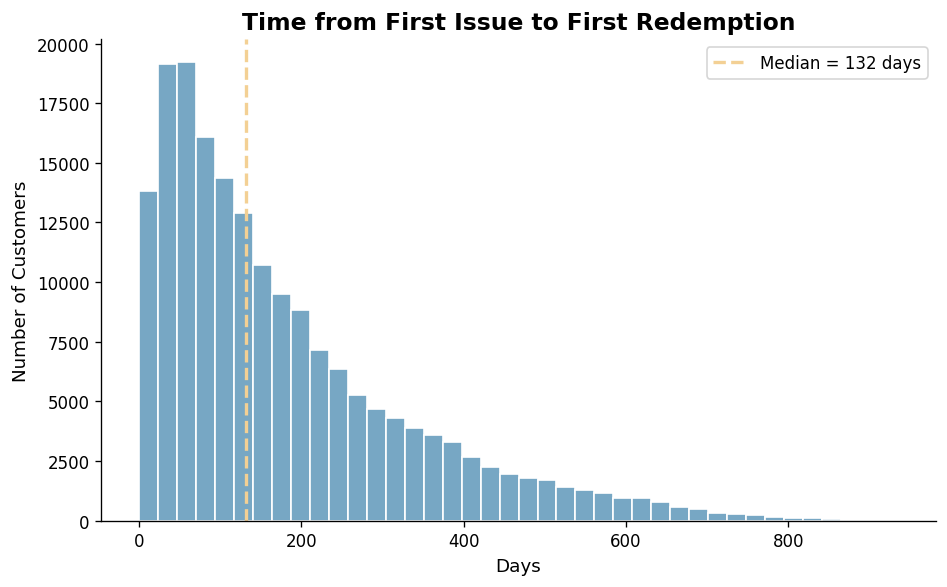

,count,mean,std,min,25%,50%,75%,max
days_to_first_redeem,"182,492.0000",180.0454,156.6758,0.0000,62.0000,132.0000,252.0000,935.0000


In [551]:
customer_population["days_to_first_redeem"] = (
    customer_population["first_redeem_date"]
    - customer_population["first_issue_date"]
).dt.days

redeem_delay = (
    customer_population["days_to_first_redeem"]
    .dropna()
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    redeem_delay,
    bins=40,
    color=COLORS["serene_sea"],
    edgecolor="white",
)

ax.axvline(
    redeem_delay.median(),
    color=COLORS["bungalow_maple"],
    linestyle="--",
    linewidth=2,
    label=f"Median = {redeem_delay.median():.0f} days",
)

ax.set_title("Time from First Issue to First Redemption")
ax.set_xlabel("Days")
ax.set_ylabel("Number of Customers")
ax.legend()

plt.tight_layout()
plt.show()

display(
    redeem_delay
    .describe()
    .to_frame("days_to_first_redeem")
    .T
)

#### Customer Population Findings

- **Gender:** `U` is the largest recorded group (**46.4%**), followed by `F` (**36.8%**) and `M` (**16.8%**). Because `U` represents a large share of customers, gender may provide limited information for part of the population.

- **Age:** The median age is **45 years**, with the middle 50% of customers between **34 and 59 years old**. The population covers a broad age range.

- **Loyalty history:** Customers joined the loyalty program at different times, with card issuance concentrated more heavily in 2017.

The customer population therefore differs in both demographic profile and loyalty history. The next step is to examine how these customers actually purchased before the campaign.

### 1.2 Historical Purchase Behavior

Customer profile tells us who the customers are. Next, we look at how they actually purchased before the campaign.

We begin with the available purchase timeline, then examine recency, frequency, spending, product behavior, and store behavior.

#### Purchase Timeline

First, check how much pre-campaign purchase history is available for the experiment customers.

In [552]:
purchase_timeline = con.sql(
    """
    WITH experiment_purchases AS (
        SELECT p.*
        FROM purchases AS p
        INNER JOIN uplift_train AS u
            USING (client_id)
    ),

    transactions AS (
        SELECT DISTINCT
            client_id,
            transaction_id,
            transaction_datetime,
            store_id
        FROM experiment_purchases
    )

    SELECT
        (SELECT MIN(transaction_datetime) FROM experiment_purchases)
            AS first_transaction,
        (SELECT MAX(transaction_datetime) FROM experiment_purchases)
            AS last_transaction,
        (SELECT COUNT(*) FROM experiment_purchases)
            AS purchase_rows,
        (SELECT COUNT(*) FROM transactions)
            AS transactions,
        (SELECT COUNT(DISTINCT client_id) FROM experiment_purchases)
            AS active_customers
    """
).df()

display(purchase_timeline)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,first_transaction,last_transaction,purchase_rows,transactions,active_customers
0,2018-11-21 21:02:33,2019-03-18 23:19:28,22882690,4024949,200039


In [553]:
monthly_purchase_activity = con.sql(
    """
    WITH transactions AS (
        SELECT DISTINCT
            p.client_id,
            p.transaction_id,
            p.transaction_datetime,
            p.store_id
        FROM purchases AS p
        INNER JOIN uplift_train AS u
            USING (client_id)
    )

    SELECT
        DATE_TRUNC('month', transaction_datetime) AS month,
        COUNT(*) AS transactions,
        COUNT(DISTINCT client_id) AS active_customers
    FROM transactions
    GROUP BY 1
    ORDER BY 1
    """
).df()

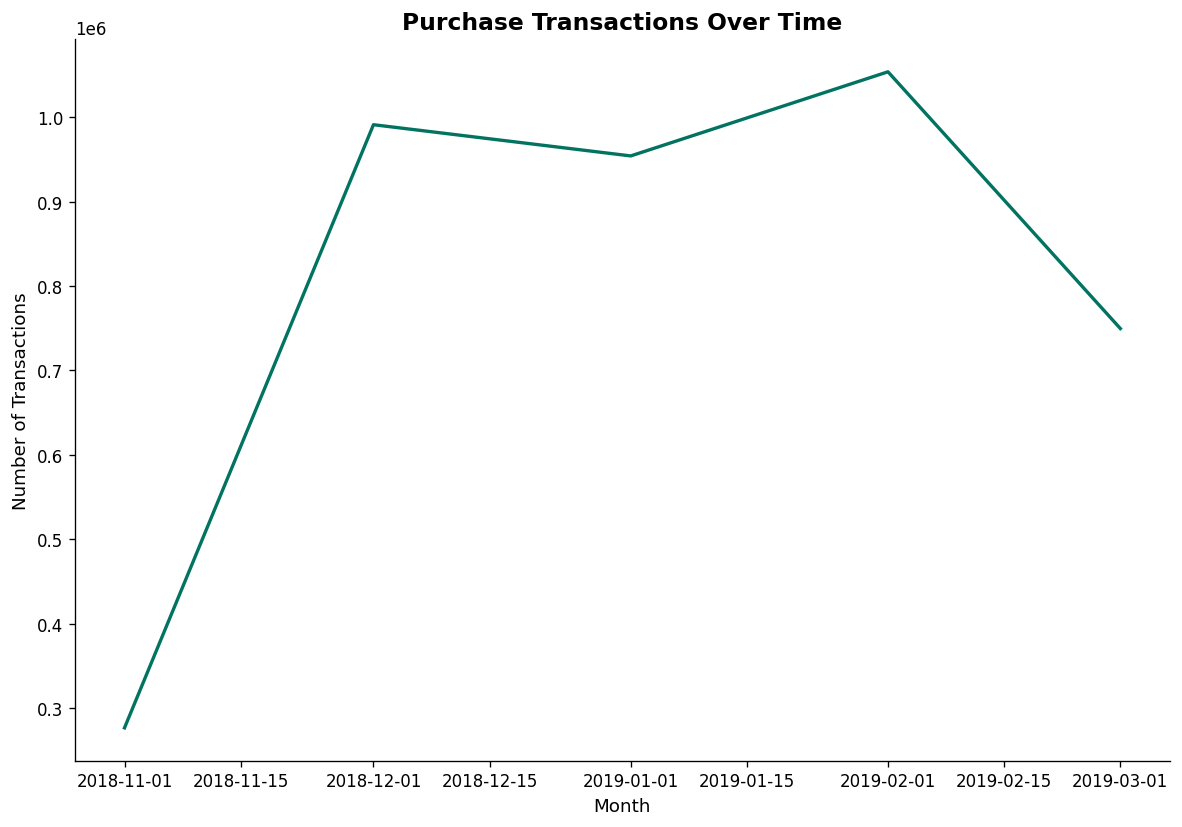

In [554]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(
    monthly_purchase_activity["month"],
    monthly_purchase_activity["transactions"],
    color=COLORS["pacific_green"],
    linewidth=2,
)

ax.set_title("Purchase Transactions Over Time")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

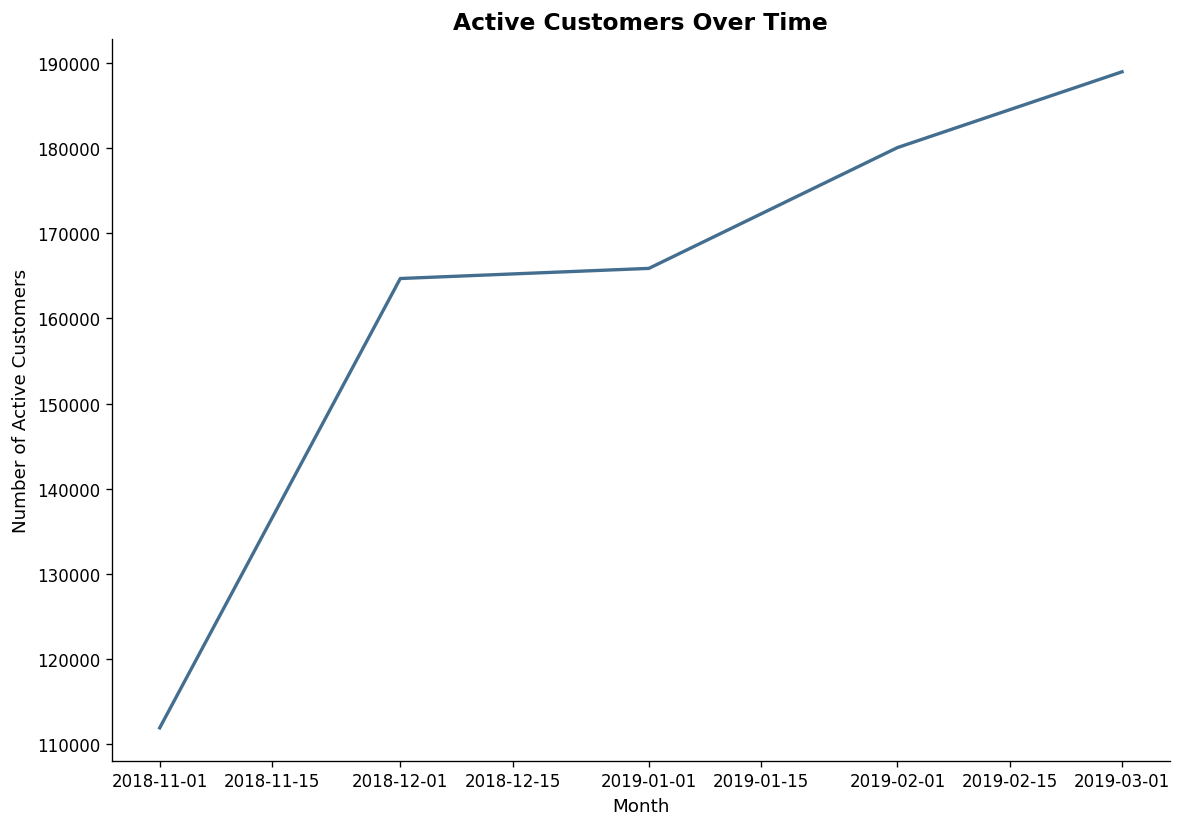

In [555]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(
    monthly_purchase_activity["month"],
    monthly_purchase_activity["active_customers"],
    color=COLORS["rainy_lake"],
    linewidth=2,
)

ax.set_title("Active Customers Over Time")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Active Customers")

plt.tight_layout()
plt.show()

#### Recency

Recency measures how long it had been since each customer's last purchase at the end of the available pre-campaign purchase history.

In [556]:
purchase_reference_date = con.sql(
    """
    SELECT MAX(p.transaction_datetime)
    FROM purchases AS p
    INNER JOIN uplift_train AS u
        USING (client_id)
    """
).fetchone()[0]

print("Purchase history reference date:", purchase_reference_date)

Purchase history reference date: 2019-03-18 23:19:28


In [557]:
customer_recency = con.sql(
    f"""
    WITH last_purchase AS (
        SELECT
            p.client_id,
            MAX(p.transaction_datetime) AS last_purchase_date
        FROM purchases AS p
        INNER JOIN uplift_train AS u
            USING (client_id)
        GROUP BY p.client_id
    )

    SELECT
        u.client_id,
        lp.last_purchase_date,
        DATE_DIFF(
            'day',
            lp.last_purchase_date,
            TIMESTAMP '{purchase_reference_date}'
        ) AS recency_days
    FROM uplift_train AS u
    LEFT JOIN last_purchase AS lp
        USING (client_id)
    """
).df()

display(customer_recency.head())

,client_id,last_purchase_date,recency_days
0,00b79be95c,2019-03-17 11:21:12,1
1,00c820390c,2019-03-06 14:26:06,12
2,00ca98d868,2019-03-04 07:44:47,14
3,00cf1c3bb5,2019-03-03 08:16:06,15
4,00cf563621,2019-03-17 07:11:33,1


In [558]:
display(
    customer_recency["recency_days"]
    .describe()
    .to_frame("recency_days")
    .T
)

,count,mean,std,min,25%,50%,75%,max
recency_days,"200,039.0000",5.8289,5.6680,0.0000,1.0000,4.0000,9.0000,22.0000


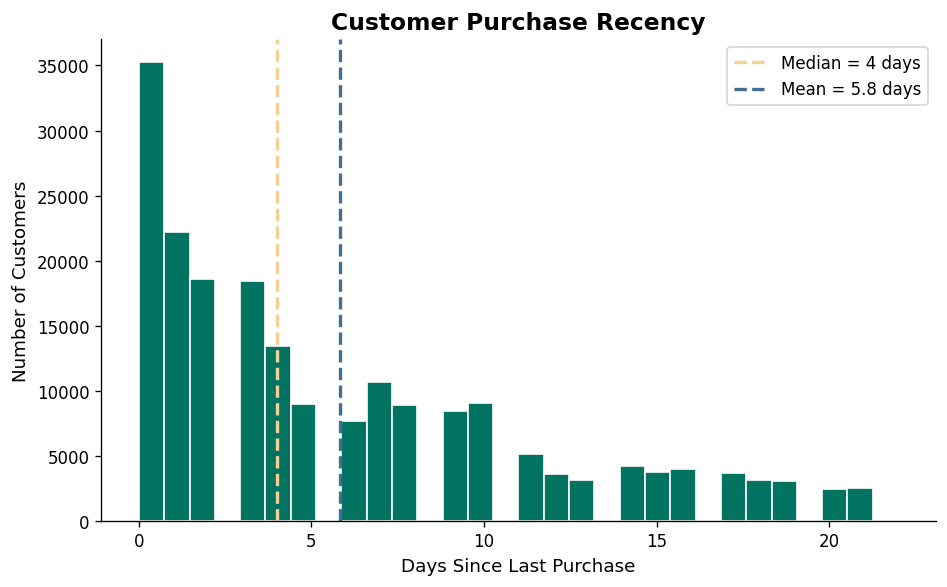

In [559]:
recency = customer_recency["recency_days"].dropna()

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    recency,
    bins=30,
    color=COLORS["pacific_green"],
    edgecolor="white",
)

ax.axvline(
    recency.median(),
    color=COLORS["bungalow_maple"],
    linestyle="--",
    linewidth=2,
    label=f"Median = {recency.median():.0f} days",
)

ax.axvline(
    recency.mean(),
    color=COLORS["rainy_lake"],
    linestyle="--",
    linewidth=2,
    label=f"Mean = {recency.mean():.1f} days",
)

ax.set_title("Customer Purchase Recency")
ax.set_xlabel("Days Since Last Purchase")
ax.set_ylabel("Number of Customers")
ax.legend()

plt.tight_layout()
plt.show()

#### Purchase Timeline and Recency Findings

* The available purchase history covers about four months, from **November 2018 to March 2019**, and all experiment customers have purchase activity in this period.
* Customers are generally very recent purchasers: the median recency is **4 days**, and 75% purchased within the last **9 days**.
* Recency still varies across customers, from **0 to 22 days**, giving a useful view of how recently each customer was active.

Recency tells us **how recently** a customer purchased, but not **how often** they purchased. The next step therefore examines purchase frequency.


#### Frequency

Frequency measures the number of purchase transactions each customer made during the available pre-campaign history.

In [560]:
customer_frequency = con.sql(
    """
    WITH transactions AS (
        SELECT DISTINCT
            p.client_id,
            p.transaction_id,
            p.transaction_datetime,
            p.store_id
        FROM purchases AS p
        INNER JOIN uplift_train AS u
            USING (client_id)
    ),

    purchase_frequency AS (
        SELECT
            client_id,
            COUNT(*) AS transaction_count,
            COUNT(DISTINCT CAST(transaction_datetime AS DATE)) AS active_days
        FROM transactions
        GROUP BY client_id
    )

    SELECT
        u.client_id,
        COALESCE(pf.transaction_count, 0) AS transaction_count,
        COALESCE(pf.active_days, 0) AS active_days
    FROM uplift_train AS u
    LEFT JOIN purchase_frequency AS pf
        USING (client_id)
    """
).df()

display(customer_frequency.head())

,client_id,transaction_count,active_days
0,044ebb948c,75,56
1,04837a0935,21,21
2,04cbe8f711,2,2
3,04d0964900,22,22
4,0bf43b6a0f,19,16


In [561]:
display(
    customer_frequency[
        ["transaction_count", "active_days"]
    ]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
transaction_count,"200,039.0000",20.1208,17.7321,1.0000,8.0000,15.0000,27.0000,320.0000
active_days,"200,039.0000",17.8742,14.2211,1.0000,8.0000,14.0000,24.0000,115.0000


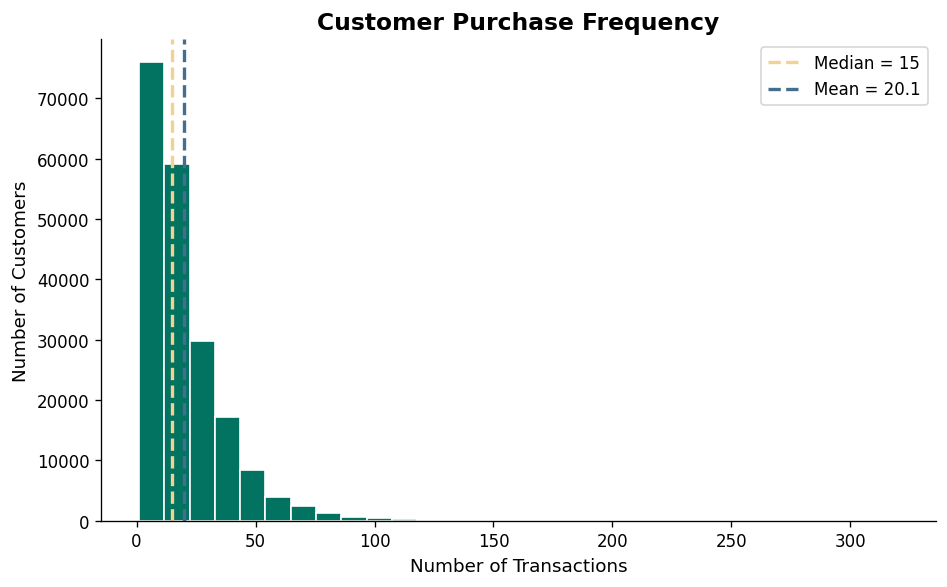

In [562]:
frequency = customer_frequency["transaction_count"]

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    frequency,
    bins=30,
    color=COLORS["pacific_green"],
    edgecolor="white",
)

ax.axvline(
    frequency.median(),
    color=COLORS["bungalow_maple"],
    linestyle="--",
    linewidth=2,
    label=f"Median = {frequency.median():.0f}",
)

ax.axvline(
    frequency.mean(),
    color=COLORS["rainy_lake"],
    linestyle="--",
    linewidth=2,
    label=f"Mean = {frequency.mean():.1f}",
)

ax.set_title("Customer Purchase Frequency")
ax.set_xlabel("Number of Transactions")
ax.set_ylabel("Number of Customers")
ax.legend()

plt.tight_layout()
plt.show()

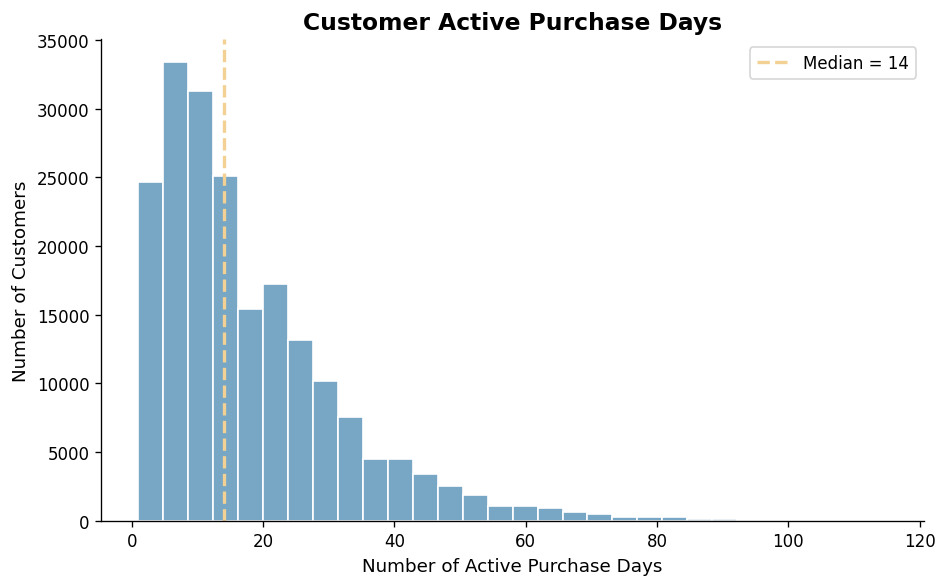

In [563]:
active_days = customer_frequency["active_days"]

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    active_days,
    bins=30,
    color=COLORS["serene_sea"],
    edgecolor="white",
)

ax.axvline(
    active_days.median(),
    color=COLORS["bungalow_maple"],
    linestyle="--",
    linewidth=2,
    label=f"Median = {active_days.median():.0f}",
)

ax.set_title("Customer Active Purchase Days")
ax.set_xlabel("Number of Active Purchase Days")
ax.set_ylabel("Number of Customers")
ax.legend()

plt.tight_layout()
plt.show()

#### Frequency Findings

* Customers made a median of **15 transactions** during the available purchase history, while the mean is higher at **20.1 transactions**.
* Half of the customers made between **8 and 27 transactions**, but a small group purchased much more frequently, producing a long right tail up to **320 transactions**.
* Customers were active on a median of **14 purchase days**, with half of the population active between **8 and 24 days**.
* The similar medians for transaction count (**15**) and active days (**14**) show that transaction frequency mostly reflects repeated shopping across different days, while some customers also make multiple transactions on the same day.

Overall, customers differ substantially in **how often they shop**, giving another behavioral dimension beyond recency.

The next step is to examine **how much they spend when they shop**.


#### Spending

- **Total spending** across the available purchase history;
- **Average transaction value** for a typical shopping transaction.

`purchase_sum` is a transaction-level value repeated across product rows, so it is counted once per unique transaction before customer-level aggregation.

In [564]:
customer_spending = con.sql(
    """
    WITH transactions AS (
        SELECT
            p.client_id,
            p.transaction_id,
            p.transaction_datetime,
            p.store_id,
            MAX(p.purchase_sum) AS transaction_value
        FROM purchases AS p
        INNER JOIN uplift_train AS u
            USING (client_id)
        GROUP BY
            p.client_id,
            p.transaction_id,
            p.transaction_datetime,
            p.store_id
    ),

    spending AS (
        SELECT
            client_id,
            SUM(transaction_value) AS total_spend,
            AVG(transaction_value) AS avg_transaction_value,
            MEDIAN(transaction_value) AS median_transaction_value
        FROM transactions
        GROUP BY client_id
    )

    SELECT
        u.client_id,
        s.total_spend,
        s.avg_transaction_value,
        s.median_transaction_value
    FROM uplift_train AS u
    LEFT JOIN spending AS s
        USING (client_id)
    """
).df()

display(customer_spending.head())

,client_id,total_spend,avg_transaction_value,median_transaction_value
0,064e945df2,"1,314.0000",187.7143,187.0000
1,06604bd8f7,"17,057.3400",437.3677,310.0000
2,0667ecd7c7,"7,812.6100",153.1884,102.9800
3,067234f529,"10,870.0000",226.4583,191.5000
4,067f81a3b6,"26,969.0700",657.7822,514.0000


In [565]:
display(
    customer_spending[
        [
            "total_spend",
            "avg_transaction_value",
            "median_transaction_value",
        ]
    ]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
total_spend,"200,039.0000","8,597.5220","8,914.5971",1.0400,"3,147.6150","6,102.4400","11,094.1850","504,490.3800"
avg_transaction_value,"200,039.0000",495.7832,374.5485,1.0400,261.2900,393.9998,608.7400,"7,694.0000"
median_transaction_value,"200,039.0000",432.2968,363.2531,1.0400,209.0000,330.9500,533.5000,"7,694.0000"


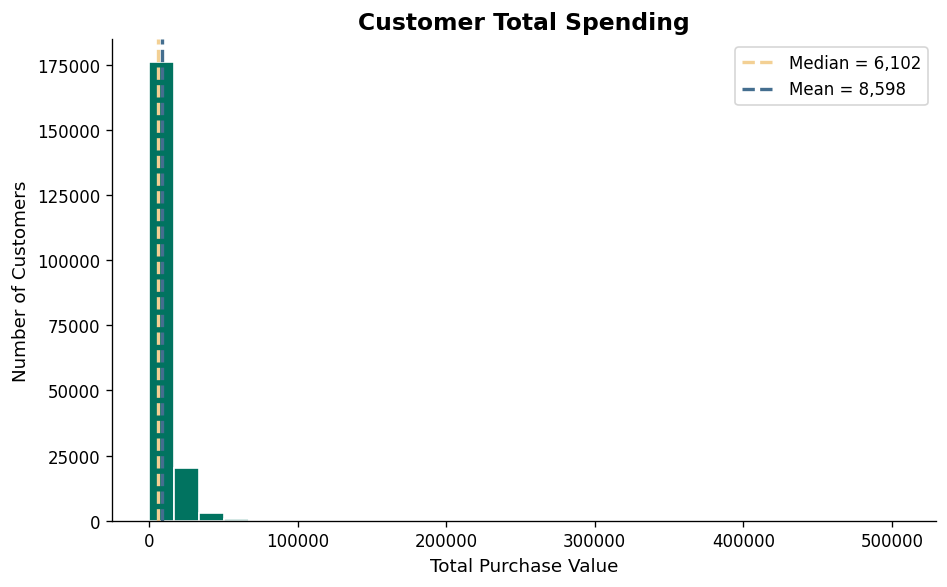

In [566]:
total_spend = customer_spending["total_spend"].dropna()

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    total_spend,
    bins=30,
    color=COLORS["pacific_green"],
    edgecolor="white",
)

ax.axvline(
    total_spend.median(),
    color=COLORS["bungalow_maple"],
    linestyle="--",
    linewidth=2,
    label=f"Median = {total_spend.median():,.0f}",
)

ax.axvline(
    total_spend.mean(),
    color=COLORS["rainy_lake"],
    linestyle="--",
    linewidth=2,
    label=f"Mean = {total_spend.mean():,.0f}",
)

ax.set_title("Customer Total Spending")
ax.set_xlabel("Total Purchase Value")
ax.set_ylabel("Number of Customers")
ax.legend()

plt.tight_layout()
plt.show()

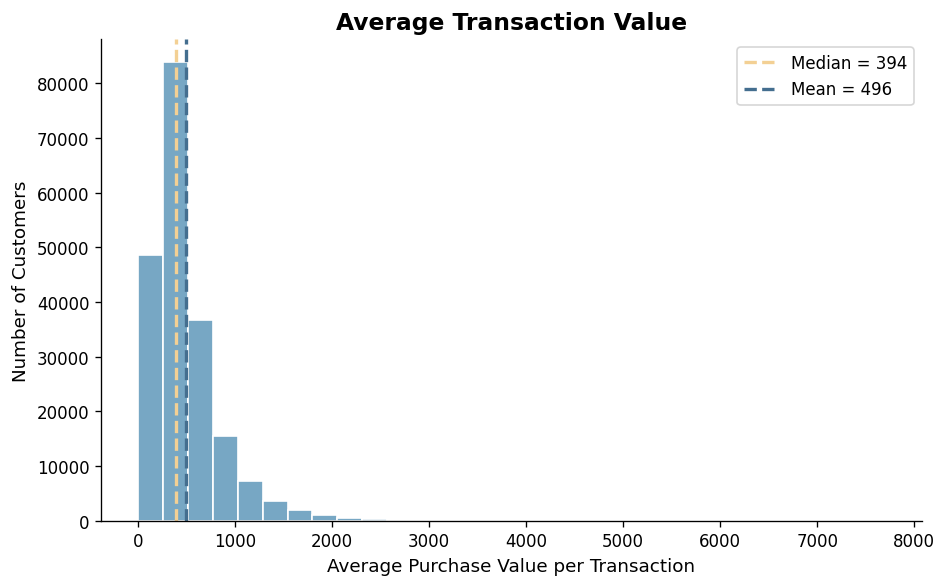

In [567]:
avg_transaction_value = (
    customer_spending["avg_transaction_value"]
    .dropna()
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    avg_transaction_value,
    bins=30,
    color=COLORS["serene_sea"],
    edgecolor="white",
)

ax.axvline(
    avg_transaction_value.median(),
    color=COLORS["bungalow_maple"],
    linestyle="--",
    linewidth=2,
    label=f"Median = {avg_transaction_value.median():,.0f}",
)

ax.axvline(
    avg_transaction_value.mean(),
    color=COLORS["rainy_lake"],
    linestyle="--",
    linewidth=2,
    label=f"Mean = {avg_transaction_value.mean():,.0f}",
)

ax.set_title("Average Transaction Value")
ax.set_xlabel("Average Purchase Value per Transaction")
ax.set_ylabel("Number of Customers")
ax.legend()

plt.tight_layout()
plt.show()

In [568]:
display(
    customer_spending[
        ["total_spend", "avg_transaction_value"]
    ]
    .quantile([0.50, 0.75, 0.90, 0.95, 0.99])
)

,total_spend,avg_transaction_value
0.5000,"6,102.4400",393.9998
0.7500,"11,094.1850",608.7400
0.9000,"18,287.1280",926.0798
0.9500,"24,235.2540","1,193.4774"
0.9900,"41,865.7384","1,896.6470"


#### Spending Findings

- Customers spent a median of about **6,102** during the available purchase history, while the mean is higher at about **8,598**.
- Most customers spend much less than the highest-spending customers: 75% spent below about **11,094**, while a small group forms a long right tail.
- A typical transaction is also relatively small, with a median average transaction value of about **394** per customer.
- Spending therefore varies both in **total customer value** and in **how much customers typically spend per shopping trip**.

Together with recency and frequency, spending adds another view of how customers behaved before the campaign.

#### Product Behavior

Recency, frequency, and spending describe when customers shop, how often they shop, and how much they spend.

The next step looks at **what they buy**.

- **Product diversity:** how many different products and product categories a customer purchased;
- **Category concentration:** whether a customer's purchases were spread across categories or concentrated in a smaller set.

The product hierarchy was already validated during data cleaning, so this section uses that structure to describe customer behavior rather than checking the product metadata again.

In [569]:
customer_product_behavior = con.sql(
    """
    WITH product_lines AS (
        SELECT
            p.client_id,
            p.product_id,
            COALESCE(pr.level_2, 'UNKNOWN') AS level_2
        FROM purchases AS p

        INNER JOIN uplift_train AS u
            USING (client_id)

        INNER JOIN products AS pr
            USING (product_id)
    ),

    product_behavior AS (
        SELECT
            client_id,
            COUNT(DISTINCT product_id) AS unique_products,
            COUNT(DISTINCT level_2) AS unique_level_2_categories
        FROM product_lines
        GROUP BY client_id
    )

    SELECT
        u.client_id,
        pb.unique_products,
        pb.unique_level_2_categories
    FROM uplift_train AS u

    LEFT JOIN product_behavior AS pb
        USING (client_id)
    """
).df()

display(customer_product_behavior.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,client_id,unique_products,unique_level_2_categories
0,08888a5cfd,36,12
1,08e15b8380,54,10
2,0904ff77d0,102,19
3,154a7ecb89,231,21
4,1599f95946,35,12


In [570]:
display(
    customer_product_behavior[
        [
            "unique_products",
            "unique_level_2_categories",
        ]
    ]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
unique_products,"200,039.0000",75.2873,56.3788,1.0000,35.0000,62.0000,101.0000,"1,364.0000"
unique_level_2_categories,"200,039.0000",12.3694,4.3468,1.0000,9.0000,12.0000,15.0000,37.0000


In [571]:
display(
    customer_product_behavior[
        [
            "unique_products",
            "unique_level_2_categories",
        ]
    ]
    .quantile([0.50, 0.75, 0.90, 0.95, 0.99])
)

,unique_products,unique_level_2_categories
0.5000,62.0000,12.0000
0.7500,101.0000,15.0000
0.9000,149.0000,18.0000
0.9500,183.0000,20.0000
0.9900,263.0000,23.0000


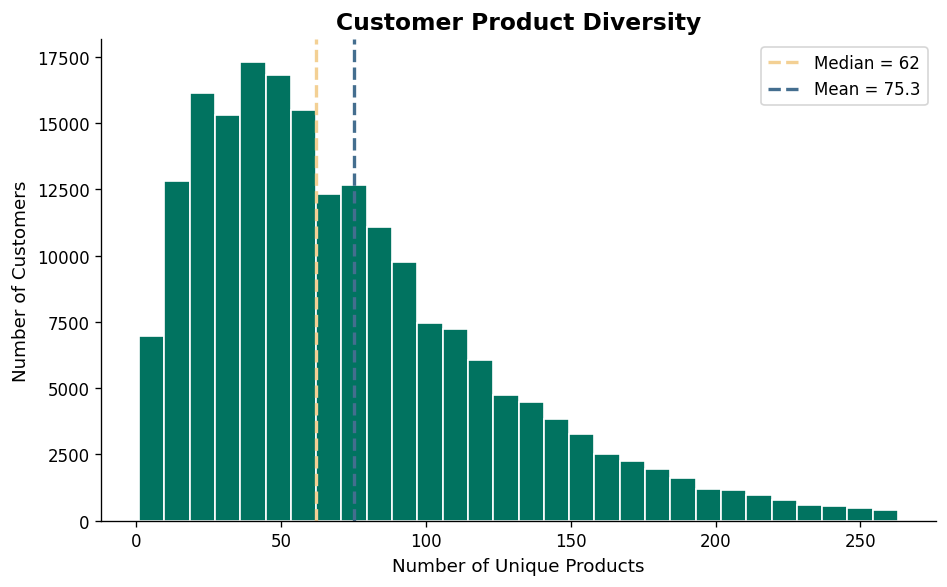

In [572]:
unique_products = (
    customer_product_behavior["unique_products"]
    .dropna()
)

product_p99 = unique_products.quantile(0.99)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    unique_products[
        unique_products <= product_p99
    ],
    bins=30,
    color=COLORS["pacific_green"],
    edgecolor="white",
)

ax.axvline(
    unique_products.median(),
    color=COLORS["bungalow_maple"],
    linestyle="--",
    linewidth=2,
    label=f"Median = {unique_products.median():.0f}",
)

ax.axvline(
    unique_products.mean(),
    color=COLORS["rainy_lake"],
    linestyle="--",
    linewidth=2,
    label=f"Mean = {unique_products.mean():.1f}",
)

ax.set_title("Customer Product Diversity")
ax.set_xlabel("Number of Unique Products")
ax.set_ylabel("Number of Customers")
ax.legend()

plt.tight_layout()
plt.show()

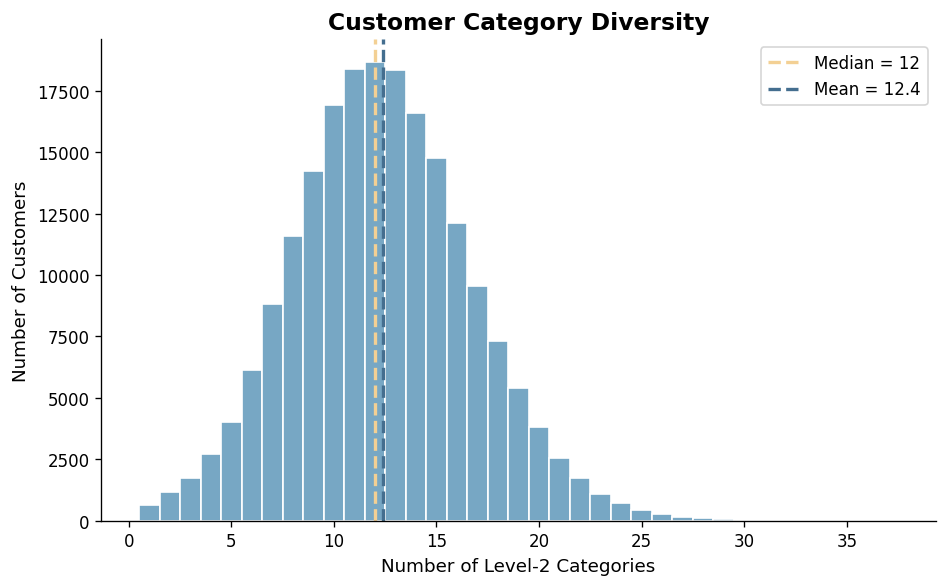

In [573]:
category_diversity = (
    customer_product_behavior[
        "unique_level_2_categories"
    ]
    .dropna()
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    category_diversity,
    bins=np.arange(
        category_diversity.min(),
        category_diversity.max() + 2,
    ) - 0.5,
    color=COLORS["serene_sea"],
    edgecolor="white",
)

ax.axvline(
    category_diversity.median(),
    color=COLORS["bungalow_maple"],
    linestyle="--",
    linewidth=2,
    label=f"Median = {category_diversity.median():.0f}",
)

ax.axvline(
    category_diversity.mean(),
    color=COLORS["rainy_lake"],
    linestyle="--",
    linewidth=2,
    label=f"Mean = {category_diversity.mean():.1f}",
)

ax.set_title("Customer Category Diversity")
ax.set_xlabel("Number of Level-2 Categories")
ax.set_ylabel("Number of Customers")
ax.legend()

plt.tight_layout()
plt.show()

In [574]:
customer_category_concentration = con.sql(
    """
    WITH product_lines AS (
        SELECT
            p.client_id,
            COALESCE(pr.level_2, 'UNKNOWN') AS level_2
        FROM purchases AS p

        INNER JOIN uplift_train AS u
            USING (client_id)

        INNER JOIN products AS pr
            USING (product_id)
    ),

    category_counts AS (
        SELECT
            client_id,
            level_2,
            COUNT(*) AS purchase_lines
        FROM product_lines
        GROUP BY
            client_id,
            level_2
    ),

    concentration AS (
        SELECT
            client_id,
            MAX(purchase_lines) * 1.0
                / SUM(purchase_lines)
                AS dominant_category_share
        FROM category_counts
        GROUP BY client_id
    )

    SELECT
        u.client_id,
        c.dominant_category_share
    FROM uplift_train AS u

    LEFT JOIN concentration AS c
        USING (client_id)
    """
).df()

display(customer_category_concentration.head())

,client_id,dominant_category_share
0,06604bd8f7,0.2412
1,0667ecd7c7,0.3118
2,068214436e,0.1288
3,06ae41da05,0.2500
4,06f6d36a74,0.4286


,count,mean,std,min,25%,50%,75%,max
dominant_category_share_pct,"200,039.0000",28.2066,10.5741,10.0000,21.2766,25.8065,32.2581,100.0000


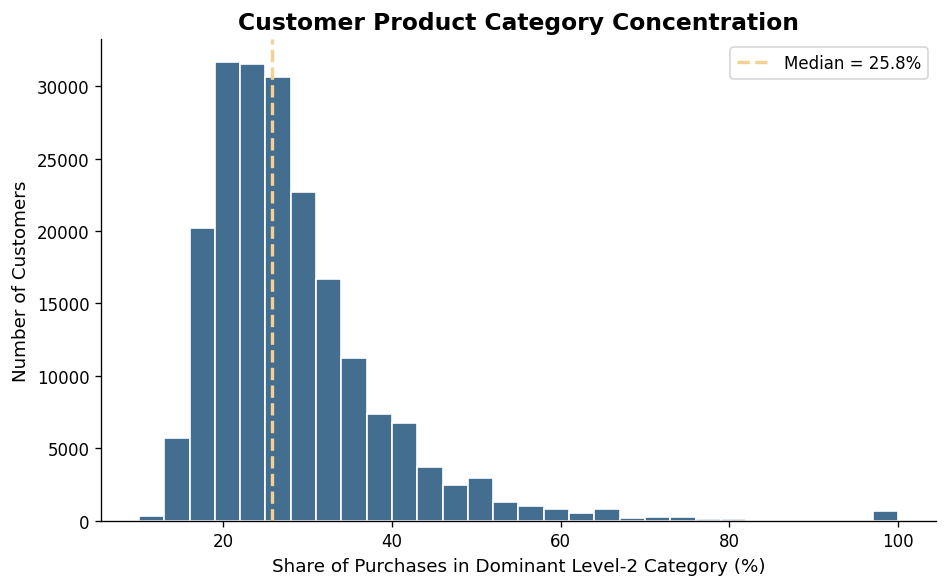

In [575]:
category_concentration = (
    customer_category_concentration[
        "dominant_category_share"
    ]
    .dropna()
    .mul(100)
)

display(
    category_concentration
    .describe()
    .to_frame("dominant_category_share_pct")
    .T
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    category_concentration,
    bins=30,
    color=COLORS["rainy_lake"],
    edgecolor="white",
)

ax.axvline(
    category_concentration.median(),
    color=COLORS["bungalow_maple"],
    linestyle="--",
    linewidth=2,
    label=f"Median = {category_concentration.median():.1f}%",
)

ax.set_title("Customer Product Category Concentration")
ax.set_xlabel("Share of Purchases in Dominant Level-2 Category (%)")
ax.set_ylabel("Number of Customers")
ax.legend()

plt.tight_layout()
plt.show()

In [576]:
customer_product_preferences = con.sql(
    """
    WITH product_lines AS (
        SELECT
            p.client_id,
            pr.is_own_trademark,
            pr.is_alcohol
        FROM purchases AS p

        INNER JOIN uplift_train AS u
            USING (client_id)

        INNER JOIN products AS pr
            USING (product_id)
    ),

    preferences AS (
        SELECT
            client_id,

            AVG(is_own_trademark) AS own_brand_share,
            AVG(is_alcohol) AS alcohol_share

        FROM product_lines
        GROUP BY client_id
    )

    SELECT
        u.client_id,
        p.own_brand_share,
        p.alcohol_share

    FROM uplift_train AS u

    LEFT JOIN preferences AS p
        USING (client_id)
    """
).df()

display(customer_product_preferences.head())

display(
    customer_product_preferences[
        ["own_brand_share", "alcohol_share"]
    ]
    .mul(100)
    .describe()
    .T
)

,client_id,own_brand_share,alcohol_share
0,0650083f2c,0.1807,0.0241
1,0653981577,0.0278,0.0000
2,06540f9303,0.3165,0.0000
3,0655d217b4,0.2979,0.0000
4,065651b271,0.1368,0.0000


,count,mean,std,min,25%,50%,75%,max
own_brand_share,"200,039.0000",15.3743,9.1275,0.0000,9.3939,14.2157,19.7674,100.0000
alcohol_share,"200,039.0000",1.8524,4.5680,0.0000,0.0000,0.0000,1.8182,100.0000


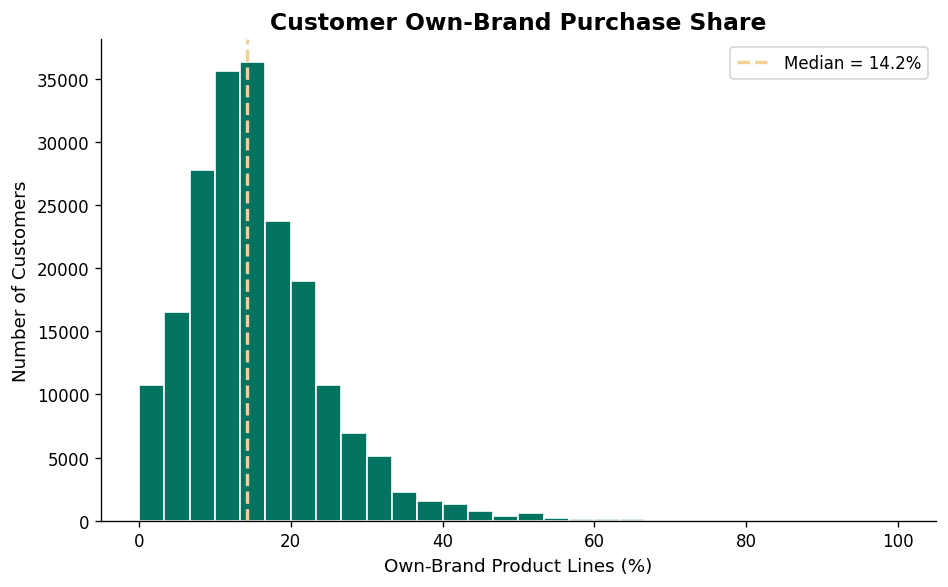

In [577]:
own_brand_share = (
    customer_product_preferences["own_brand_share"]
    .dropna()
    .mul(100)
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    own_brand_share,
    bins=30,
    color=COLORS["pacific_green"],
    edgecolor="white",
)

ax.axvline(
    own_brand_share.median(),
    color=COLORS["bungalow_maple"],
    linestyle="--",
    linewidth=2,
    label=f"Median = {own_brand_share.median():.1f}%",
)

ax.set_title("Customer Own-Brand Purchase Share")
ax.set_xlabel("Own-Brand Product Lines (%)")
ax.set_ylabel("Number of Customers")
ax.legend()

plt.tight_layout()
plt.show()

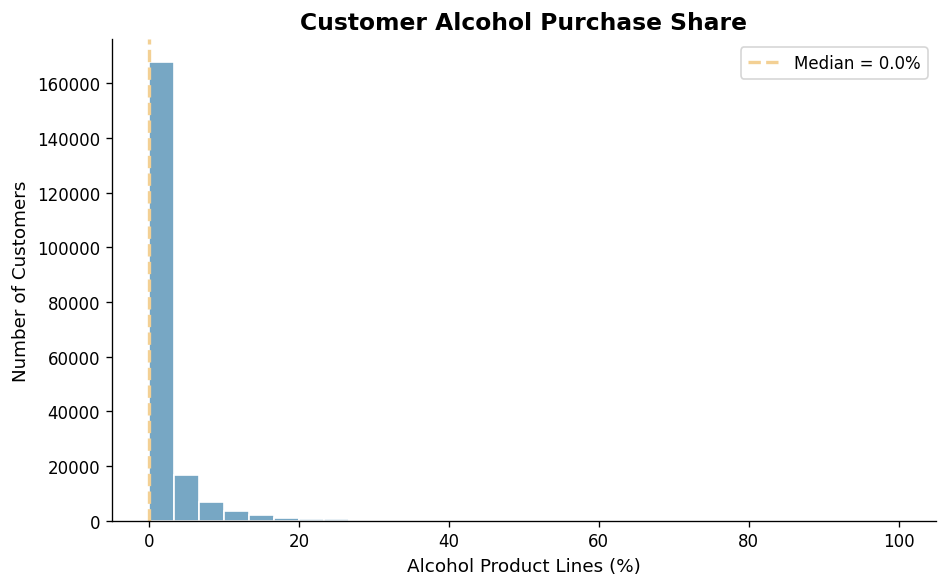

In [578]:
alcohol_share = (
    customer_product_preferences["alcohol_share"]
    .dropna()
    .mul(100)
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    alcohol_share,
    bins=30,
    color=COLORS["serene_sea"],
    edgecolor="white",
)

ax.axvline(
    alcohol_share.median(),
    color=COLORS["bungalow_maple"],
    linestyle="--",
    linewidth=2,
    label=f"Median = {alcohol_share.median():.1f}%",
)

ax.set_title("Customer Alcohol Purchase Share")
ax.set_xlabel("Alcohol Product Lines (%)")
ax.set_ylabel("Number of Customers")
ax.legend()

plt.tight_layout()
plt.show()

Beyond product diversity and category concentration, customers may also differ in the types of products they tend to purchase. Two available product attributes provide simple preference signals:

* The share of purchased product lines that are the retailer's **own-brand products**;
* The share of purchased product lines that are **alcohol products**.

Own-brand products make up a median of about **14.2%** of each customer's purchased product lines. The middle 50% of customers are roughly between **9.4% and 19.8%**, showing that own-brand preference varies across customers but is not dominated by extreme values.

Alcohol purchases are much less common. The median alcohol share is **0%**, meaning that at least half of customers did not purchase any alcohol products during the available history. The mean alcohol share is only about **1.9%**, while 75% of customers have an alcohol share below about **1.8%**. This suggests that a relatively small group of customers accounts for the higher alcohol-purchase shares.

Together, these patterns show that customers differ not only in **how broadly they shop**, but also in **what types of products they tend to choose**.


#### Store Behavior

Customers may also differ in where they shop.

- **Store diversity:** how many different stores a customer visited;
- **Store concentration:** how strongly the customer's transactions were concentrated in their most frequently visited store.

In [579]:
customer_store_behavior = con.sql(
    """
    WITH transactions AS (
        SELECT DISTINCT
            p.client_id,
            p.transaction_id,
            p.transaction_datetime,
            p.store_id
        FROM purchases AS p

        INNER JOIN uplift_train AS u
            USING (client_id)
    ),

    store_counts AS (
        SELECT
            client_id,
            store_id,
            COUNT(*) AS transactions
        FROM transactions
        GROUP BY
            client_id,
            store_id
    ),

    store_behavior AS (
        SELECT
            client_id,
            COUNT(*) AS unique_stores,
            MAX(transactions) * 1.0
                / SUM(transactions) AS dominant_store_share
        FROM store_counts
        GROUP BY client_id
    )

    SELECT
        u.client_id,
        sb.unique_stores,
        sb.dominant_store_share
    FROM uplift_train AS u

    LEFT JOIN store_behavior AS sb
        USING (client_id)
    """
).df()

display(customer_store_behavior.head())

,client_id,unique_stores,dominant_store_share
0,12ab5dcecb,3,0.8421
1,3776253cf8,7,0.4231
2,28311d6340,2,0.6471
3,4ad854d2bc,2,0.9615
4,8b1cb30d06,2,0.8824


In [580]:
store_behavior_summary = (
    customer_store_behavior[
        ["unique_stores", "dominant_store_share"]
    ]
    .copy()
)

store_behavior_summary["dominant_store_share"] *= 100

display(
    store_behavior_summary
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
unique_stores,"200,039.0000",2.9207,2.0052,1.0000,2.0000,2.0000,4.0000,95.0000
dominant_store_share,"200,039.0000",75.1867,22.2447,4.5455,57.1429,79.1667,98.9899,100.0000


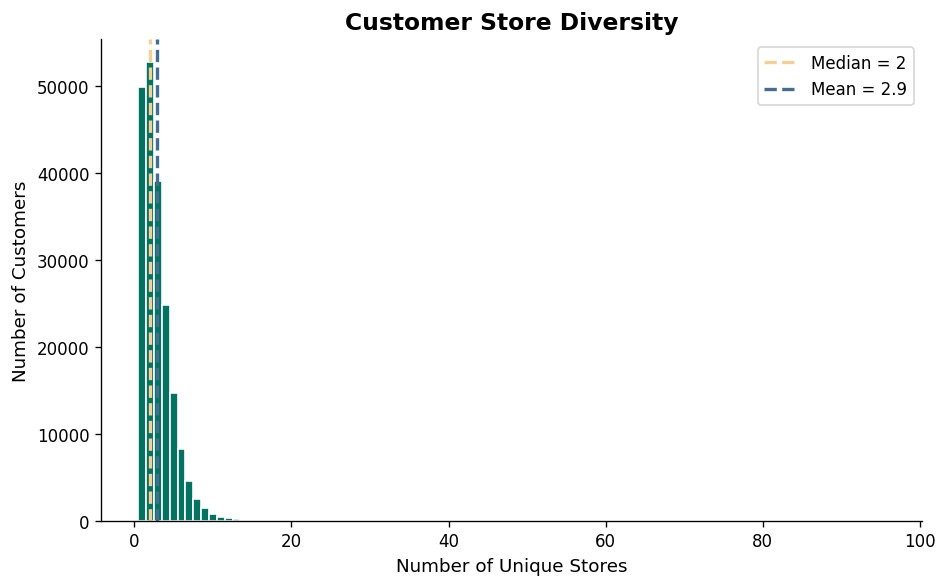

In [581]:
unique_stores = (
    customer_store_behavior["unique_stores"]
    .dropna()
)

fig, ax = plt.subplots(figsize=(8, 5))

bins = np.arange(
    unique_stores.min(),
    unique_stores.max() + 2,
) - 0.5

ax.hist(
    unique_stores,
    bins=bins,
    color=COLORS["pacific_green"],
    edgecolor="white",
)

ax.axvline(
    unique_stores.median(),
    color=COLORS["bungalow_maple"],
    linestyle="--",
    linewidth=2,
    label=f"Median = {unique_stores.median():.0f}",
)

ax.axvline(
    unique_stores.mean(),
    color=COLORS["rainy_lake"],
    linestyle="--",
    linewidth=2,
    label=f"Mean = {unique_stores.mean():.1f}",
)

ax.set_title("Customer Store Diversity")
ax.set_xlabel("Number of Unique Stores")
ax.set_ylabel("Number of Customers")
ax.legend()

plt.tight_layout()
plt.show()

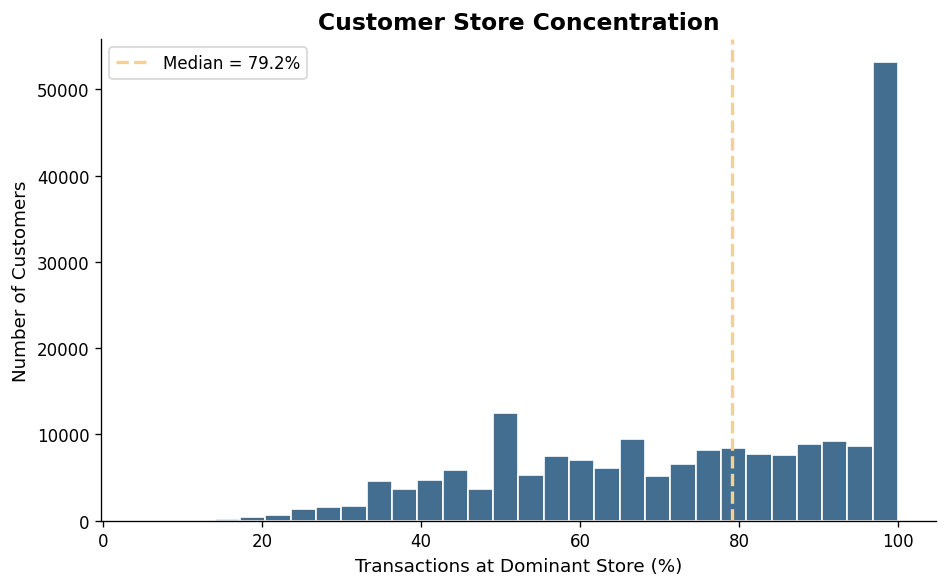

In [582]:
dominant_store_share = (
    customer_store_behavior["dominant_store_share"]
    .dropna()
    .mul(100)
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    dominant_store_share,
    bins=30,
    color=COLORS["rainy_lake"],
    edgecolor="white",
)

ax.axvline(
    dominant_store_share.median(),
    color=COLORS["bungalow_maple"],
    linestyle="--",
    linewidth=2,
    label=f"Median = {dominant_store_share.median():.1f}%",
)

ax.set_title("Customer Store Concentration")
ax.set_xlabel("Transactions at Dominant Store (%)")
ax.set_ylabel("Number of Customers")
ax.legend()

plt.tight_layout()
plt.show()

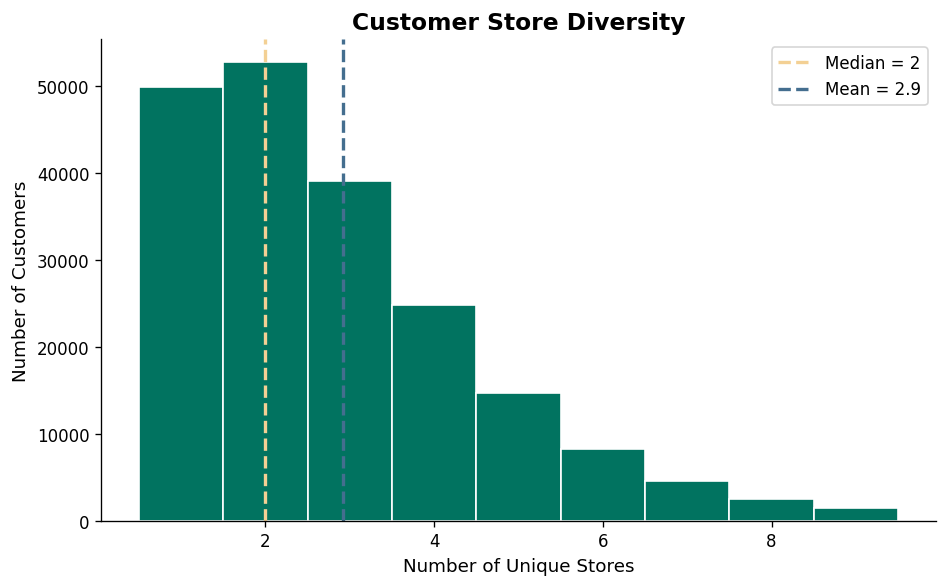

In [583]:
unique_stores = (
    customer_store_behavior["unique_stores"]
    .dropna()
)

store_p99 = unique_stores.quantile(0.99)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    unique_stores[unique_stores <= store_p99],
    bins=np.arange(1, int(store_p99) + 2) - 0.5,
    color=COLORS["pacific_green"],
    edgecolor="white",
)

ax.axvline(
    unique_stores.median(),
    color=COLORS["bungalow_maple"],
    linestyle="--",
    linewidth=2,
    label=f"Median = {unique_stores.median():.0f}",
)

ax.axvline(
    unique_stores.mean(),
    color=COLORS["rainy_lake"],
    linestyle="--",
    linewidth=2,
    label=f"Mean = {unique_stores.mean():.1f}",
)

ax.set_title("Customer Store Diversity")
ax.set_xlabel("Number of Unique Stores")
ax.set_ylabel("Number of Customers")
ax.legend()

plt.tight_layout()
plt.show()

#### Store Behavior Findings

- Customers usually shop at a small number of stores. The median customer visited **2 stores**, and 75% visited no more than **4** during the available purchase history.
- Store behavior is highly concentrated: the median customer made about **79.2%** of their transactions at their most frequently visited store.
- For 25% of customers, almost all transactions were made at the same store, while a smaller group spread their purchases across many stores.
- A few customers visited unusually many stores, with the maximum reaching **95**, but these cases are far from the typical customer pattern.

Overall, most customers show a clear **preferred-store pattern**, although the strength of that preference varies across the population.

### Customer and Purchase Behavior Summary

The pre-campaign history shows a customer population that is generally active, but with clear differences in shopping intensity and preferences.

- Customers purchased recently, with a median recency of **4 days**, and typically made **15 transactions across 14 active days** during the available history.
- Spending varies considerably. The median customer spent about **6,102** in total, with an average transaction value of about **394**.
- Customers usually purchased a fairly broad range of products: the median customer bought **62 unique products across 12 level-2 categories**.
- Purchases were generally spread across product categories, with the dominant category accounting for a median of only **25.8%** of purchase lines.
- Own-brand products accounted for a median of **14.2%** of purchase lines, while alcohol purchases were uncommon, with a median share of **0%**.
- Customers usually visited only a few stores: the median was **2 stores**, and about **79.2%** of transactions were concentrated in their most frequently visited store.

Overall, customers differ noticeably in **shopping activity, spending, product choice, and store loyalty**. These differences provide the behavioral patterns that can later be checked against campaign response.

## 2. Treatment and Outcome

The experiment structure has already shown that treatment and control contain approximately equal numbers of customers.

The next question is whether their **observed purchase outcomes after the campaign** differ.

This provides the overall campaign picture before examining whether the treatment effect changes across different customer behaviors.

In [584]:
outcome_distribution = con.sql(
    """
    SELECT
        target,
        COUNT(*) AS customers,
        COUNT(*) * 100.0
            / SUM(COUNT(*)) OVER () AS percentage
    FROM uplift_train
    GROUP BY target
    ORDER BY target
    """
).df()

display(outcome_distribution)

,target,customers,percentage
0,0,76037,38.0111
1,1,124002,61.9889


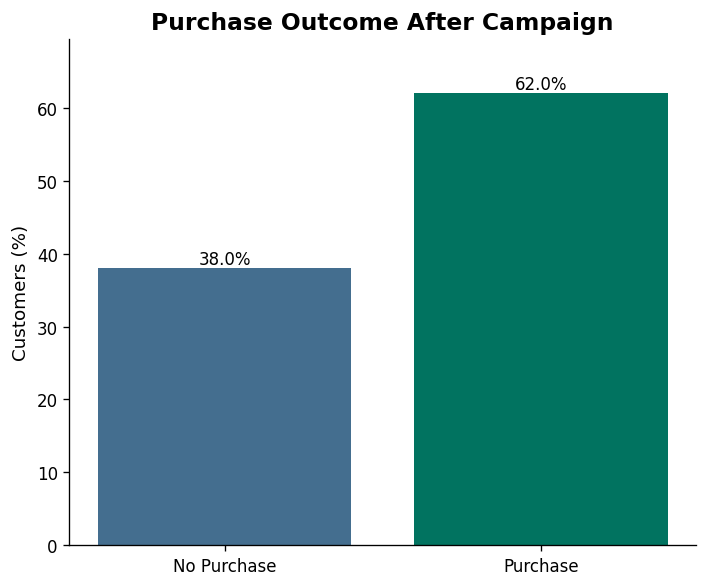

In [585]:
fig, ax = plt.subplots(figsize=(6, 5))

bars = ax.bar(
    ["No Purchase", "Purchase"],
    outcome_distribution["percentage"],
    color=[
        COLORS["rainy_lake"],
        COLORS["pacific_green"],
    ],
)

ax.set_title("Purchase Outcome After Campaign")
ax.set_ylabel("Customers (%)")

for bar, value in zip(
    bars,
    outcome_distribution["percentage"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
    )

ax.set_ylim(
    0,
    outcome_distribution["percentage"].max() * 1.12,
)

plt.tight_layout()
plt.show()

In [586]:
treatment_outcome = con.sql(
    """
    SELECT
        treatment_flg,
        COUNT(*) AS customers,
        AVG(target) * 100 AS purchase_rate
    FROM uplift_train
    GROUP BY treatment_flg
    ORDER BY treatment_flg
    """
).df()

treatment_outcome["group"] = [
    "Control",
    "Treatment",
]

display(
    treatment_outcome[
        ["group", "customers", "purchase_rate"]
    ]
)

,group,customers,purchase_rate
0,Control,100058,60.3280
1,Treatment,99981,63.6511


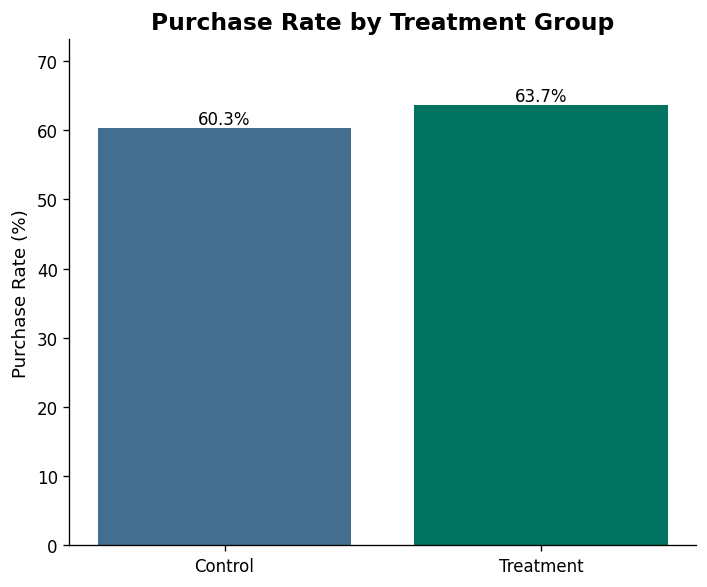

In [587]:
fig, ax = plt.subplots(figsize=(6, 5))

bars = ax.bar(
    treatment_outcome["group"],
    treatment_outcome["purchase_rate"],
    color=[
        COLORS["rainy_lake"],
        COLORS["pacific_green"],
    ],
)

ax.set_title("Purchase Rate by Treatment Group")
ax.set_ylabel("Purchase Rate (%)")

for bar, value in zip(
    bars,
    treatment_outcome["purchase_rate"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
    )

ax.set_ylim(
    0,
    treatment_outcome["purchase_rate"].max() * 1.15,
)

plt.tight_layout()
plt.show()

In [588]:
control_rate = treatment_outcome.loc[
    treatment_outcome["treatment_flg"] == 0,
    "purchase_rate",
].iloc[0]

treatment_rate = treatment_outcome.loc[
    treatment_outcome["treatment_flg"] == 1,
    "purchase_rate",
].iloc[0]

observed_difference = treatment_rate - control_rate

print(f"Control purchase rate:   {control_rate:.2f}%")
print(f"Treatment purchase rate: {treatment_rate:.2f}%")
print(f"Observed difference:     {observed_difference:+.2f} percentage points")

Control purchase rate:   60.33%
Treatment purchase rate: 63.65%
Observed difference:     +3.32 percentage points


### Treatment and Outcome Findings

- Overall, **62.0%** of customers made a purchase after the campaign period, while **38.0%** did not.
- The control group had a purchase rate of **60.33%**.
- The treatment group had a higher purchase rate of **63.65%**.
- The observed difference between treatment and control is therefore **+3.32 percentage points**.

This shows a positive overall difference in purchase rate between the treatment and control groups.

However, the overall average does not tell us whether all customers responded in the same way. The next step is therefore to examine whether this treatment-control difference changes across different pre-campaign customer behaviors.

## 3. Treatment Effect Across Customer Behavior

Overall, the treatment group has a **3.32 percentage-point higher purchase rate** than the control group.

However, this overall difference may hide different customer responses.

The next step checks whether the treatment-control purchase-rate difference changes across the pre-campaign behavior patterns identified earlier.

The analysis starts with:

- Recency;
- Frequency;
- Spending;
- Product behavior;
- Store behavior.

At this stage, the treatment-control difference is used as an **observed pattern**. Patterns found here will later be turned into hypotheses and checked before making feature-engineering decisions.

In [589]:
behavior_analysis = con.sql(
    """
    SELECT
        client_id,
        treatment_flg,
        target
    FROM uplift_train
    """
).df()

behavior_frames = [
    customer_recency,
    customer_frequency,
    customer_spending,
    customer_product_behavior,
    customer_category_concentration,
    customer_product_preferences,
    customer_store_behavior,
]

for frame in behavior_frames:
    behavior_analysis = behavior_analysis.merge(
        frame,
        on="client_id",
        how="left",
        validate="one_to_one",
    )

print(f"Customers: {len(behavior_analysis):,}")

display(behavior_analysis.head())

Customers: 200,039


,client_id,treatment_flg,target,last_purchase_date,recency_days,transaction_count,active_days,total_spend,avg_transaction_value,median_transaction_value,unique_products,unique_level_2_categories,dominant_category_share,own_brand_share,alcohol_share,unique_stores,dominant_store_share
0,000012768d,0,1,2019-03-14 15:01:47,4,4,4,"2,803.0000",700.7500,688.5000,46,8,0.3269,0.0769,0.0000,3,0.5000
1,000036f903,1,1,2019-03-17 10:29:37,1,32,32,"9,805.0000",306.4062,267.0000,96,12,0.2346,0.0864,0.0062,5,0.7812
2,00010925a5,1,1,2019-03-08 07:09:50,10,18,17,"5,883.0000",326.8333,301.0000,58,10,0.4103,0.1154,0.0128,2,0.6111
3,0001f552b0,1,1,2019-03-16 10:54:02,2,15,13,"6,155.1800",410.3453,335.3700,79,13,0.1977,0.1163,0.0000,4,0.6667
4,00020e7b18,1,1,2019-03-15 12:04:23,3,18,16,"25,819.6100","1,434.4228","1,222.6750",175,13,0.2831,0.1618,0.0000,4,0.6667


### 3.1 Recency

Customers differ in how recently they purchased before the campaign.

The question is:

> **Does the treatment-control purchase-rate difference change depending on how recently a customer purchased?**

Customers are grouped by recency using the observed distribution. Lower recency means the customer purchased more recently.

In [590]:
recency_effect = behavior_analysis[
    [
        "client_id",
        "treatment_flg",
        "target",
        "recency_days",
    ]
].dropna().copy()

recency_effect["recency_group"] = pd.qcut(
    recency_effect["recency_days"],
    q=4,
    duplicates="drop",
)

In [591]:
recency_group_profile = (
    recency_effect
    .groupby(
        "recency_group",
        observed=True,
    )
    .agg(
        customers=("client_id", "size"),
        min_days=("recency_days", "min"),
        max_days=("recency_days", "max"),
        median_days=("recency_days", "median"),
    )
)

recency_rates = (
    recency_effect
    .groupby(
        [
            "recency_group",
            "treatment_flg",
        ],
        observed=True,
    )["target"]
    .mean()
    .mul(100)
    .unstack("treatment_flg")
    .rename(
        columns={
            0: "control_rate",
            1: "treatment_rate",
        }
    )
)

recency_summary = (
    recency_group_profile
    .join(recency_rates)
)

recency_summary["observed_difference_pp"] = (
    recency_summary["treatment_rate"]
    - recency_summary["control_rate"]
)

display(
    recency_summary.reset_index(drop=True)
)

,customers,min_days,max_days,median_days,control_rate,treatment_rate,observed_difference_pp
0,57451,0,1,0.0000,80.1029,82.5807,2.4777
1,50462,2,4,3.0000,67.5431,70.1472,2.6041
2,44658,5,9,7.0000,50.3361,54.7436,4.4074
3,47468,10,22,14.0000,38.0908,42.2461,4.1553


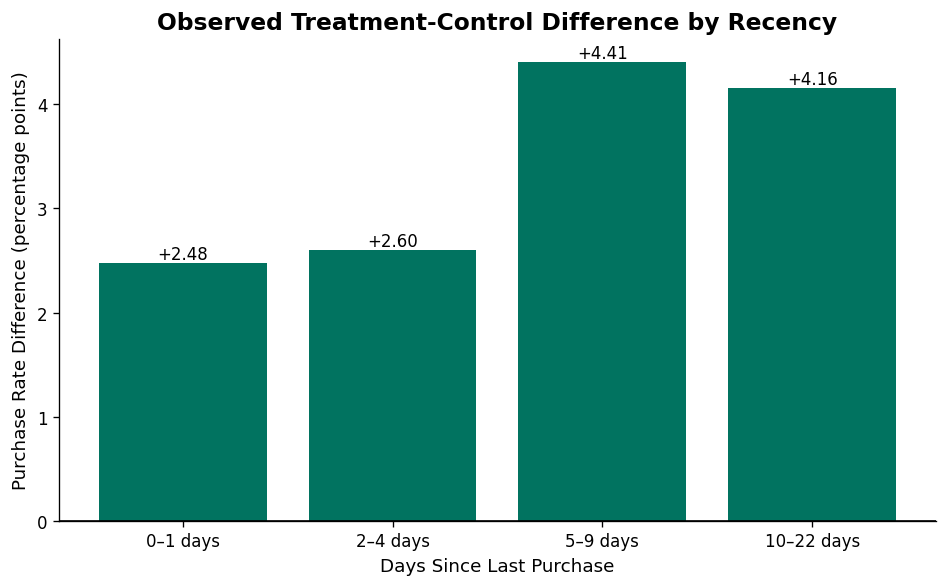

In [592]:
recency_labels = []

for row in recency_summary.itertuples():
    min_days = int(row.min_days)
    max_days = int(row.max_days)

    if min_days == max_days:
        label = f"{min_days} days"
    else:
        label = f"{min_days}–{max_days} days"

    recency_labels.append(label)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    recency_labels,
    recency_summary["observed_difference_pp"],
    color=COLORS["pacific_green"],
)

ax.axhline(
    0,
    color="black",
    linewidth=1,
)

ax.set_title("Observed Treatment-Control Difference by Recency")
ax.set_xlabel("Days Since Last Purchase")
ax.set_ylabel("Purchase Rate Difference (percentage points)")

for bar, value in zip(
    bars,
    recency_summary["observed_difference_pp"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:+.2f}",
        ha="center",
        va="bottom" if value >= 0 else "top",
    )

plt.tight_layout()
plt.show()

#### Recency Findings

- Customers who purchased very recently have much higher purchase rates overall. For customers whose last purchase was within **0–1 days**, purchase rates are above **80%** in both treatment and control.
- Purchase rates decrease as recency increases, reaching about **38.1%** for control and **42.2%** for treatment among customers whose last purchase was **10–22 days** ago.
- However, the observed treatment-control difference moves in the opposite direction:
  - **0–1 days:** +2.48 percentage points;
  - **2–4 days:** +2.60 percentage points;
  - **5–9 days:** +4.41 percentage points;
  - **10–22 days:** +4.16 percentage points.
- The campaign difference is therefore smaller among very recent purchasers and larger among customers who had not purchased for several days.

This suggests that **recency may be related to heterogeneous campaign response**. The pattern should later be checked formally before using it as evidence for feature-engineering decisions.

### 3.2 Frequency

Customers also differ in how frequently they purchased before the campaign.

The question is:

> **Does the treatment-control purchase-rate difference change with purchase frequency?**

Customers are grouped by their number of pre-campaign transactions to compare campaign response across different levels of shopping activity.

In [593]:
frequency_effect = behavior_analysis[
    [
        "client_id",
        "treatment_flg",
        "target",
        "transaction_count",
    ]
].dropna().copy()

frequency_effect["frequency_group"] = pd.qcut(
    frequency_effect["transaction_count"],
    q=4,
    duplicates="drop",
)

In [594]:
frequency_group_profile = (
    frequency_effect
    .groupby(
        "frequency_group",
        observed=True,
    )
    .agg(
        customers=("client_id", "size"),
        min_transactions=("transaction_count", "min"),
        max_transactions=("transaction_count", "max"),
        median_transactions=("transaction_count", "median"),
    )
)

frequency_rates = (
    frequency_effect
    .groupby(
        [
            "frequency_group",
            "treatment_flg",
        ],
        observed=True,
    )["target"]
    .mean()
    .mul(100)
    .unstack("treatment_flg")
    .rename(
        columns={
            0: "control_rate",
            1: "treatment_rate",
        }
    )
)

frequency_summary = (
    frequency_group_profile
    .join(frequency_rates)
)

frequency_summary["observed_difference_pp"] = (
    frequency_summary["treatment_rate"]
    - frequency_summary["control_rate"]
)

display(
    frequency_summary.reset_index(drop=True)
)

,customers,min_transactions,max_transactions,median_transactions,control_rate,treatment_rate,observed_difference_pp
0,53315,1,8,5.0000,32.4286,36.8403,4.4117
1,48377,9,15,12.0000,53.3267,57.7857,4.4590
2,50584,16,27,21.0000,71.1453,73.5675,2.4223
3,47763,28,320,39.0000,87.3766,88.7656,1.3891


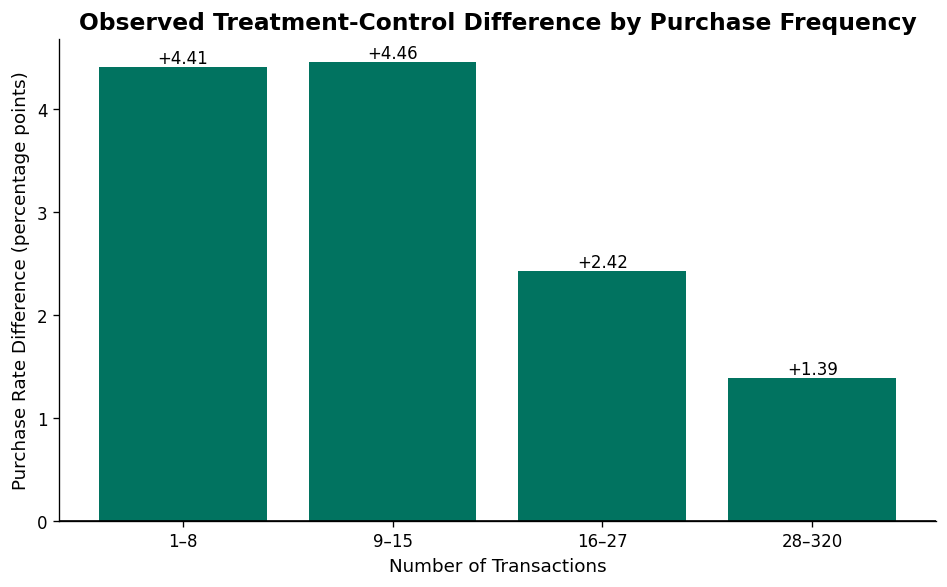

In [595]:
frequency_labels = []

for row in frequency_summary.itertuples():
    min_transactions = int(row.min_transactions)
    max_transactions = int(row.max_transactions)

    if min_transactions == max_transactions:
        label = f"{min_transactions}"
    else:
        label = f"{min_transactions}–{max_transactions}"

    frequency_labels.append(label)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    frequency_labels,
    frequency_summary["observed_difference_pp"],
    color=COLORS["pacific_green"],
)

ax.axhline(
    0,
    color="black",
    linewidth=1,
)

ax.set_title(
    "Observed Treatment-Control Difference by Purchase Frequency"
)
ax.set_xlabel("Number of Transactions")
ax.set_ylabel(
    "Purchase Rate Difference (percentage points)"
)

for bar, value in zip(
    bars,
    frequency_summary["observed_difference_pp"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:+.2f}",
        ha="center",
        va="bottom" if value >= 0 else "top",
    )

plt.tight_layout()
plt.show()

#### Frequency Findings

- Customers who purchased more frequently also had much higher purchase rates overall.
- Among customers with only **1–8 transactions**, the control purchase rate was **32.43%**, compared with **36.84%** for treatment.
- Purchase rates increased steadily with frequency, reaching about **87.38%** for control and **88.77%** for treatment among customers with **28 or more transactions**.
- However, the treatment-control difference became smaller as purchase frequency increased:
  - **1–8 transactions:** +4.41 percentage points;
  - **9–15 transactions:** +4.46 percentage points;
  - **16–27 transactions:** +2.42 percentage points;
  - **28–320 transactions:** +1.39 percentage points.

The observed campaign difference is therefore largest among customers with **low to moderate purchase frequency**, while highly frequent customers already have very high purchase rates even without treatment.

This suggests that purchase frequency may help distinguish customers who are likely to purchase anyway from customers whose behavior may be more responsive to the campaign.

### 3.3 Spending

Customers also differ in how much they spent before the campaign.

The question is:

> **Does the treatment-control purchase-rate difference change across customers with different spending levels?**

Customers are first grouped by their total pre-campaign spending.

In [596]:
spending_effect = behavior_analysis[
    [
        "client_id",
        "treatment_flg",
        "target",
        "total_spend",
    ]
].dropna().copy()

spending_effect["spending_group"] = pd.qcut(
    spending_effect["total_spend"],
    q=4,
    duplicates="drop",
)

In [597]:
spending_group_profile = (
    spending_effect
    .groupby(
        "spending_group",
        observed=True,
    )
    .agg(
        customers=("client_id", "size"),
        min_spend=("total_spend", "min"),
        max_spend=("total_spend", "max"),
        median_spend=("total_spend", "median"),
    )
)

spending_rates = (
    spending_effect
    .groupby(
        [
            "spending_group",
            "treatment_flg",
        ],
        observed=True,
    )["target"]
    .mean()
    .mul(100)
    .unstack("treatment_flg")
    .rename(
        columns={
            0: "control_rate",
            1: "treatment_rate",
        }
    )
)

spending_summary = (
    spending_group_profile
    .join(spending_rates)
)

spending_summary["observed_difference_pp"] = (
    spending_summary["treatment_rate"]
    - spending_summary["control_rate"]
)

display(
    spending_summary.reset_index(drop=True)
)

,customers,min_spend,max_spend,median_spend,control_rate,treatment_rate,observed_difference_pp
0,50010,1.0400,"3,147.6100","1,832.0000",37.2197,42.4529,5.2332
1,50010,"3,147.6200","6,102.4400","4,518.9600",55.5374,59.0778,3.5404
2,50009,"6,102.6700","11,094.0000","8,127.9100",68.4695,71.3916,2.9221
3,50010,"11,094.3700","504,490.3800","16,479.9100",80.3763,81.4159,1.0396


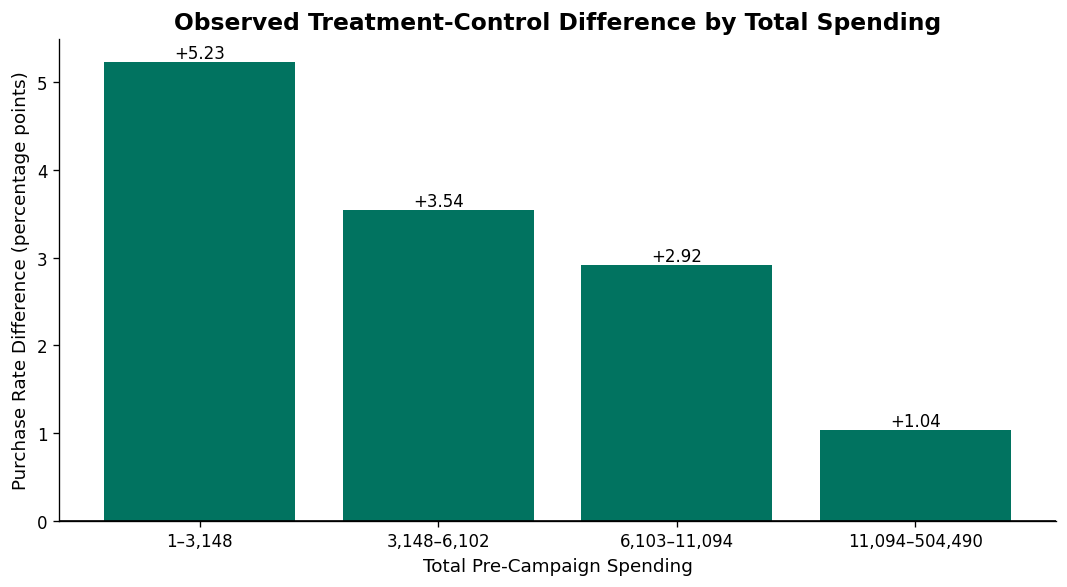

In [598]:
spending_labels = []

for row in spending_summary.itertuples():
    min_spend = row.min_spend
    max_spend = row.max_spend

    label = (
        f"{min_spend:,.0f}–{max_spend:,.0f}"
    )

    spending_labels.append(label)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    spending_labels,
    spending_summary["observed_difference_pp"],
    color=COLORS["pacific_green"],
)

ax.axhline(
    0,
    color="black",
    linewidth=1,
)

ax.set_title(
    "Observed Treatment-Control Difference by Total Spending"
)
ax.set_xlabel("Total Pre-Campaign Spending")
ax.set_ylabel(
    "Purchase Rate Difference (percentage points)"
)

for bar, value in zip(
    bars,
    spending_summary["observed_difference_pp"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:+.2f}",
        ha="center",
        va="bottom" if value >= 0 else "top",
    )


plt.tight_layout()
plt.show()

#### Spending Findings

- Customers with higher pre-campaign spending also had much higher purchase rates afterward.
- In the lowest-spending group, the control purchase rate was **37.22%**, compared with **42.45%** for treatment.
- In the highest-spending group, purchase rates were already very high: **80.38%** for control and **81.42%** for treatment.
- At the same time, the observed treatment-control difference decreased steadily as spending increased:
  - **1–3,148:** +5.23 percentage points;
  - **3,148–6,102:** +3.54 percentage points;
  - **6,103–11,094:** +2.92 percentage points;
  - **11,094–504,490:** +1.04 percentage points.

The largest observed campaign difference appears among **lower-spending customers**, while high-spending customers already have a high purchase rate even without treatment.

Together with recency and frequency, this strengthens the pattern that highly active customers are more likely to purchase anyway, while the campaign difference may be larger among less active customers.

### 3.4 Product Behavior

Customers also differ in the types and variety of products they purchase.

The analysis first checks two product patterns:

- **Category diversity:** how broadly a customer shops across product categories;
- **Category concentration:** how strongly purchases are concentrated in one main category.

The question is whether these product patterns are associated with different treatment-control purchase-rate differences.

In [599]:
category_diversity_effect = behavior_analysis[
    [
        "client_id",
        "treatment_flg",
        "target",
        "unique_level_2_categories",
    ]
].dropna().copy()

category_diversity_effect["category_diversity_group"] = pd.qcut(
    category_diversity_effect["unique_level_2_categories"],
    q=4,
    duplicates="drop",
)

In [600]:
category_diversity_profile = (
    category_diversity_effect
    .groupby(
        "category_diversity_group",
        observed=True,
    )
    .agg(
        customers=("client_id", "size"),
        min_categories=("unique_level_2_categories", "min"),
        max_categories=("unique_level_2_categories", "max"),
        median_categories=("unique_level_2_categories", "median"),
    )
)

category_diversity_rates = (
    category_diversity_effect
    .groupby(
        [
            "category_diversity_group",
            "treatment_flg",
        ],
        observed=True,
    )["target"]
    .mean()
    .mul(100)
    .unstack("treatment_flg")
    .rename(
        columns={
            0: "control_rate",
            1: "treatment_rate",
        }
    )
)

category_diversity_summary = (
    category_diversity_profile
    .join(category_diversity_rates)
)

category_diversity_summary["observed_difference_pp"] = (
    category_diversity_summary["treatment_rate"]
    - category_diversity_summary["control_rate"]
)

display(
    category_diversity_summary.reset_index(drop=True)
)

,customers,min_categories,max_categories,median_categories,control_rate,treatment_rate,observed_difference_pp
0,51058,1,9,8.0000,42.3271,47.8509,5.5238
1,53987,10,12,11.0000,58.1956,61.7064,3.5108
2,49688,13,15,14.0000,66.6599,69.2172,2.5573
3,45306,16,37,18.0000,76.3411,77.5554,1.2143


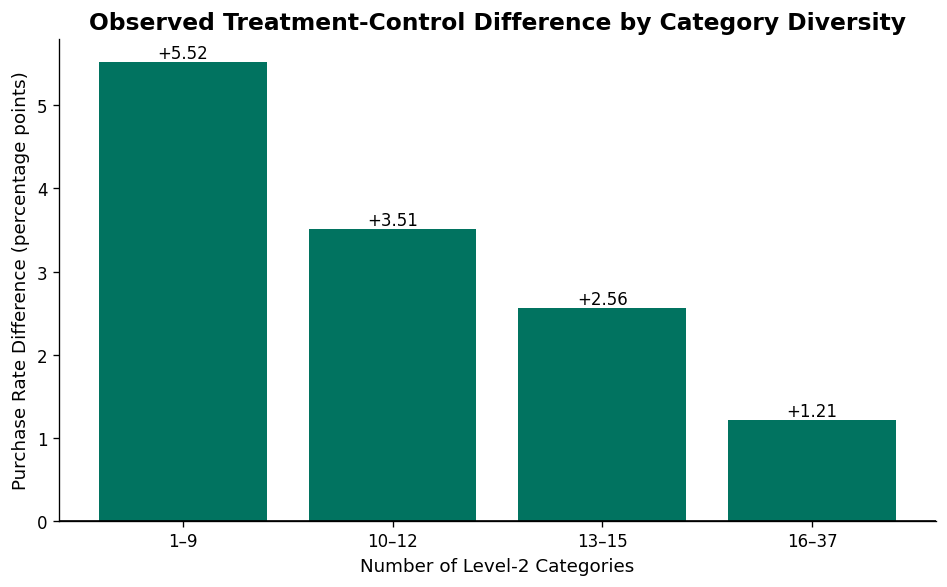

In [601]:
category_labels = []

for row in category_diversity_summary.itertuples():
    min_categories = int(row.min_categories)
    max_categories = int(row.max_categories)

    if min_categories == max_categories:
        label = f"{min_categories}"
    else:
        label = f"{min_categories}–{max_categories}"

    category_labels.append(label)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    category_labels,
    category_diversity_summary["observed_difference_pp"],
    color=COLORS["pacific_green"],
)

ax.axhline(
    0,
    color="black",
    linewidth=1,
)

ax.set_title(
    "Observed Treatment-Control Difference by Category Diversity"
)
ax.set_xlabel("Number of Level-2 Categories")
ax.set_ylabel(
    "Purchase Rate Difference (percentage points)"
)

for bar, value in zip(
    bars,
    category_diversity_summary["observed_difference_pp"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:+.2f}",
        ha="center",
        va="bottom" if value >= 0 else "top",
    )

plt.tight_layout()
plt.show()

#### Category Diversity Findings

- Customers who purchased across more product categories also had higher purchase rates overall.
- In the lowest-diversity group, with **1–9 level-2 categories**, the control purchase rate was **42.33%**, compared with **47.85%** for treatment.
- Purchase rates increased with category diversity, reaching about **76.34%** for control and **77.56%** for treatment among customers purchasing across **16–37 categories**.
- At the same time, the observed treatment-control difference decreased steadily as category diversity increased:
  - **1–9 categories:** +5.52 percentage points;
  - **10–12 categories:** +3.51 percentage points;
  - **13–15 categories:** +2.56 percentage points;
  - **16–37 categories:** +1.21 percentage points.

Customers with broader product-category activity are therefore more likely to purchase regardless of treatment, while the observed campaign difference is larger among customers with narrower category activity.

This follows the same general pattern seen for frequency and spending: customers who are already highly active tend to have higher purchase rates but smaller treatment-control differences.

#### Category Concentration

Category diversity shows how broadly customers shop. Category concentration looks at the opposite side: how much of a customer's purchase activity is concentrated in their dominant product category.

The question is:

> **Does the treatment-control purchase-rate difference change with category concentration?**

In [602]:
category_concentration_effect = behavior_analysis[
    [
        "client_id",
        "treatment_flg",
        "target",
        "dominant_category_share",
    ]
].dropna().copy()

category_concentration_effect["category_concentration_group"] = pd.qcut(
    category_concentration_effect["dominant_category_share"],
    q=4,
    duplicates="drop",
)

In [603]:
category_concentration_profile = (
    category_concentration_effect
    .groupby(
        "category_concentration_group",
        observed=True,
    )
    .agg(
        customers=("client_id", "size"),
        min_share=("dominant_category_share", "min"),
        max_share=("dominant_category_share", "max"),
        median_share=("dominant_category_share", "median"),
    )
)

category_concentration_rates = (
    category_concentration_effect
    .groupby(
        [
            "category_concentration_group",
            "treatment_flg",
        ],
        observed=True,
    )["target"]
    .mean()
    .mul(100)
    .unstack("treatment_flg")
    .rename(
        columns={
            0: "control_rate",
            1: "treatment_rate",
        }
    )
)

category_concentration_summary = (
    category_concentration_profile
    .join(category_concentration_rates)
)

category_concentration_summary["observed_difference_pp"] = (
    category_concentration_summary["treatment_rate"]
    - category_concentration_summary["control_rate"]
)

display(
    category_concentration_summary.reset_index(drop=True)
)

,customers,min_share,max_share,median_share,control_rate,treatment_rate,observed_difference_pp
0,50023,0.1000,0.2128,0.1886,65.3795,67.1583,1.7788
1,50164,0.2128,0.2581,0.2353,62.7405,65.8882,3.1476
2,50095,0.2581,0.3226,0.2857,60.6566,64.4206,3.7640
3,49757,0.3227,1.0000,0.3846,52.5258,57.0669,4.5411


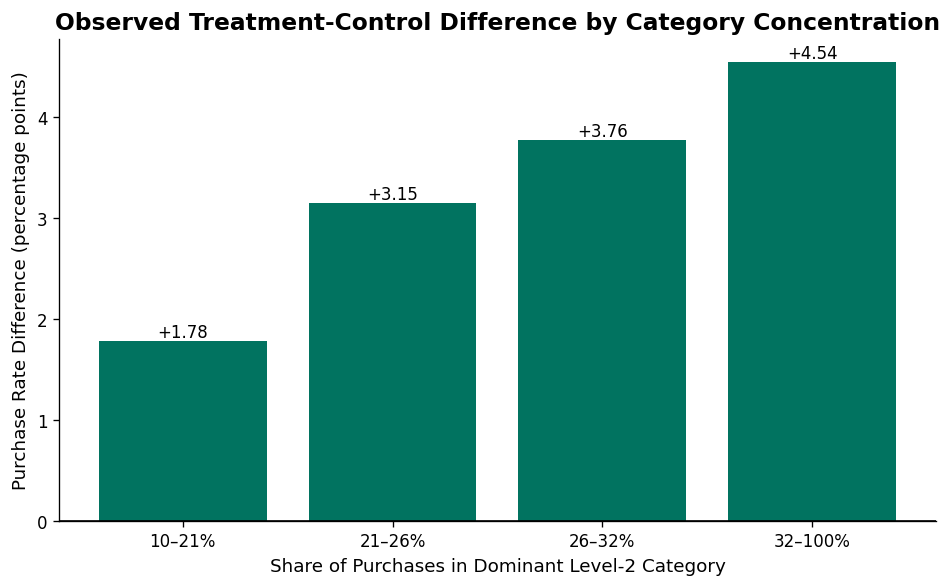

In [604]:
concentration_labels = []

for row in category_concentration_summary.itertuples():
    min_share = row.min_share * 100
    max_share = row.max_share * 100

    label = f"{min_share:.0f}–{max_share:.0f}%"
    concentration_labels.append(label)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    concentration_labels,
    category_concentration_summary["observed_difference_pp"],
    color=COLORS["pacific_green"],
)

ax.axhline(
    0,
    color="black",
    linewidth=1,
)

ax.set_title(
    "Observed Treatment-Control Difference by Category Concentration"
)
ax.set_xlabel("Share of Purchases in Dominant Level-2 Category")
ax.set_ylabel(
    "Purchase Rate Difference (percentage points)"
)

for bar, value in zip(
    bars,
    category_concentration_summary["observed_difference_pp"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:+.2f}",
        ha="center",
        va="bottom" if value >= 0 else "top",
    )

plt.tight_layout()
plt.show()

#### Category Concentration Findings

- Customers whose purchases were spread more evenly across categories had higher purchase rates overall.
- In the lowest-concentration group, where the dominant category represented only **10–21%** of purchase lines, the control purchase rate was **65.38%**, compared with **67.16%** for treatment.
- As purchases became more concentrated in one category, overall purchase rates decreased.
- At the same time, the observed treatment-control difference increased steadily:
  - **10–21% concentration:** +1.78 percentage points;
  - **21–26%:** +3.15 percentage points;
  - **26–32%:** +3.76 percentage points;
  - **32–100%:** +4.54 percentage points.

Customers with more concentrated product behavior therefore have lower purchase rates overall, but show a larger observed treatment-control difference.

Together with category diversity, this suggests that customers with **narrower product activity** may respond differently to the campaign than customers who already shop broadly across many categories.

#### Own-Brand Preference

Product diversity and concentration describe how broadly customers shop. Own-brand share provides a different view: whether customers differ in the type of products they tend to choose.

The question is:

> **Does the treatment-control purchase-rate difference change with own-brand purchase preference?**

In [605]:
own_brand_effect = behavior_analysis[
    [
        "client_id",
        "treatment_flg",
        "target",
        "own_brand_share",
    ]
].dropna().copy()

own_brand_effect["own_brand_group"] = pd.qcut(
    own_brand_effect["own_brand_share"],
    q=4,
    duplicates="drop",
)

In [606]:
own_brand_profile = (
    own_brand_effect
    .groupby(
        "own_brand_group",
        observed=True,
    )
    .agg(
        customers=("client_id", "size"),
        min_share=("own_brand_share", "min"),
        max_share=("own_brand_share", "max"),
        median_share=("own_brand_share", "median"),
    )
)

own_brand_rates = (
    own_brand_effect
    .groupby(
        ["own_brand_group", "treatment_flg"],
        observed=True,
    )["target"]
    .mean()
    .mul(100)
    .unstack("treatment_flg")
    .rename(
        columns={
            0: "control_rate",
            1: "treatment_rate",
        }
    )
)

own_brand_summary = own_brand_profile.join(
    own_brand_rates
)

own_brand_summary["observed_difference_pp"] = (
    own_brand_summary["treatment_rate"]
    - own_brand_summary["control_rate"]
)

display(
    own_brand_summary.reset_index(drop=True)
)

,customers,min_share,max_share,median_share,control_rate,treatment_rate,observed_difference_pp
0,50012,0.0000,0.0939,0.0625,60.5213,64.6201,4.0988
1,50012,0.0940,0.1422,0.1186,63.7436,66.1453,2.4017
2,50020,0.1422,0.1977,0.1667,60.7473,63.8706,3.1233
3,49995,0.1977,1.0000,0.2500,56.3090,59.9729,3.6639


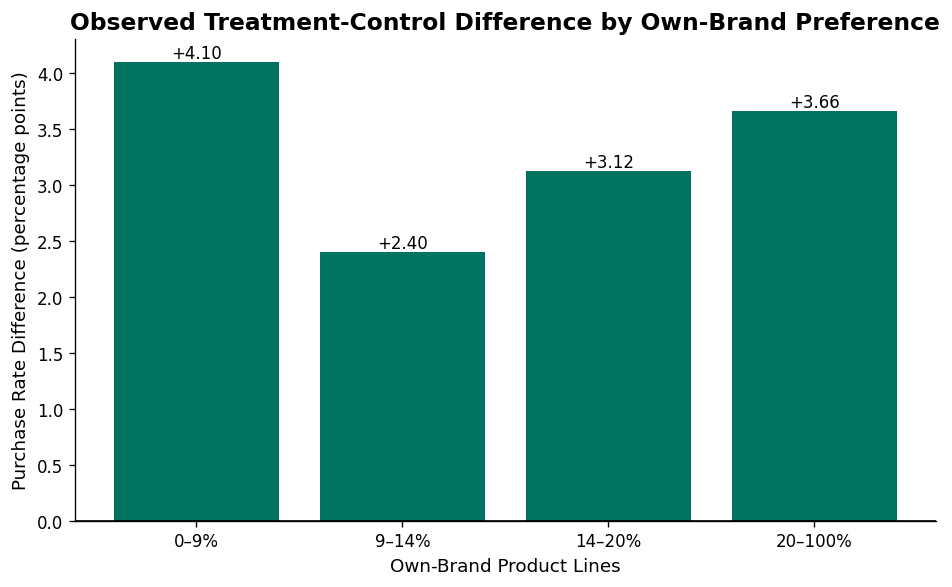

In [607]:
own_brand_labels = []

for row in own_brand_summary.itertuples():
    min_share = row.min_share * 100
    max_share = row.max_share * 100

    own_brand_labels.append(
        f"{min_share:.0f}–{max_share:.0f}%"
    )

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    own_brand_labels,
    own_brand_summary["observed_difference_pp"],
    color=COLORS["pacific_green"],
)

ax.axhline(
    0,
    color="black",
    linewidth=1,
)

ax.set_title(
    "Observed Treatment-Control Difference by Own-Brand Preference"
)
ax.set_xlabel("Own-Brand Product Lines")
ax.set_ylabel(
    "Purchase Rate Difference (percentage points)"
)

for bar, value in zip(
    bars,
    own_brand_summary["observed_difference_pp"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:+.2f}",
        ha="center",
        va="bottom" if value >= 0 else "top",
    )

plt.tight_layout()
plt.show()

#### Own-Brand Preference Findings

- Purchase rates and treatment-control differences vary across own-brand preference groups, but there is **no clear monotonic pattern**.
- The observed treatment-control differences are:
  - **0–9% own-brand share:** +4.10 percentage points;
  - **9–14%:** +2.40 percentage points;
  - **14–20%:** +3.12 percentage points;
  - **20–100%:** +3.66 percentage points.
- The smallest difference appears in the second group, while both lower and higher own-brand shares show larger differences.

Unlike activity, spending, and category-diversity measures, own-brand preference does not show a simple relationship with the observed campaign response.

It may still contain useful customer information, but this EDA does not provide a strong directional pattern to prioritize on its own.

### 3.5 Store Behavior

Customers also differ in how strongly their purchases are tied to a preferred store.

The analysis focuses on **store concentration**: the share of a customer's transactions made at their most frequently visited store.

The question is:

> **Does the treatment-control purchase-rate difference change with store concentration?**

In [608]:
store_concentration_effect = behavior_analysis[
    [
        "client_id",
        "treatment_flg",
        "target",
        "dominant_store_share",
    ]
].dropna().copy()

store_concentration_effect["store_concentration_group"] = pd.qcut(
    store_concentration_effect["dominant_store_share"],
    q=4,
    duplicates="drop",
)

In [609]:
store_concentration_profile = (
    store_concentration_effect
    .groupby(
        "store_concentration_group",
        observed=True,
    )
    .agg(
        customers=("client_id", "size"),
        min_share=("dominant_store_share", "min"),
        max_share=("dominant_store_share", "max"),
        median_share=("dominant_store_share", "median"),
    )
)

store_concentration_rates = (
    store_concentration_effect
    .groupby(
        [
            "store_concentration_group",
            "treatment_flg",
        ],
        observed=True,
    )["target"]
    .mean()
    .mul(100)
    .unstack("treatment_flg")
    .rename(
        columns={
            0: "control_rate",
            1: "treatment_rate",
        }
    )
)

store_concentration_summary = (
    store_concentration_profile
    .join(store_concentration_rates)
)

store_concentration_summary["observed_difference_pp"] = (
    store_concentration_summary["treatment_rate"]
    - store_concentration_summary["control_rate"]
)

display(
    store_concentration_summary.reset_index(drop=True)
)

,customers,min_share,max_share,median_share,control_rate,treatment_rate,observed_difference_pp
0,51730,0.0455,0.5714,0.4667,57.7159,60.7271,3.0112
1,48381,0.5726,0.7917,0.6757,61.5312,65.0570,3.5258
2,49919,0.7922,0.9899,0.8889,70.1548,72.4257,2.2708
3,50009,0.9900,1.0000,1.0000,52.0624,56.5523,4.4899


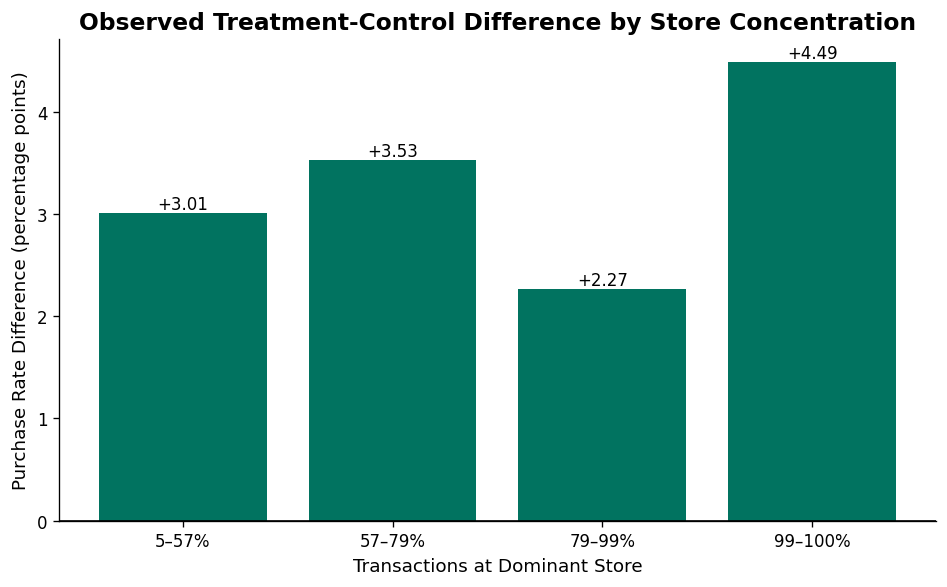

In [610]:
store_concentration_labels = []

for row in store_concentration_summary.itertuples():
    min_share = row.min_share * 100
    max_share = row.max_share * 100

    store_concentration_labels.append(
        f"{min_share:.0f}–{max_share:.0f}%"
    )

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    store_concentration_labels,
    store_concentration_summary["observed_difference_pp"],
    color=COLORS["pacific_green"],
)

ax.axhline(
    0,
    color="black",
    linewidth=1,
)

ax.set_title(
    "Observed Treatment-Control Difference by Store Concentration"
)
ax.set_xlabel("Transactions at Dominant Store")
ax.set_ylabel(
    "Purchase Rate Difference (percentage points)"
)

for bar, value in zip(
    bars,
    store_concentration_summary["observed_difference_pp"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:+.2f}",
        ha="center",
        va="bottom" if value >= 0 else "top",
    )

plt.tight_layout()
plt.show()

#### Store Concentration Findings

- The observed treatment-control difference varies across store-concentration groups, but there is **no clear monotonic pattern**.
- The differences are:
  - **5–57% concentration:** +3.01 percentage points;
  - **57–79%:** +3.53 percentage points;
  - **79–99%:** +2.27 percentage points;
  - **99–100%:** +4.49 percentage points.
- Customers in the **79–99%** group already have relatively high purchase rates in both control and treatment, while customers whose purchases are almost entirely concentrated in one store show lower overall purchase rates but the largest treatment-control difference.

Store concentration therefore appears related to customer behavior, but the relationship with campaign response is not simple or directional.

Unlike frequency, spending, and product-category behavior, store concentration does not provide a strong standalone pattern from this EDA.

#### Number of Stores

Store concentration shows how dominant one store is, but customers may also differ simply in how many stores they use.

The next check compares customers who shop at one, two, several, or many stores.

In [611]:
store_diversity_effect = behavior_analysis[
    [
        "client_id",
        "treatment_flg",
        "target",
        "unique_stores",
    ]
].dropna().copy()

store_diversity_effect["store_group"] = pd.cut(
    store_diversity_effect["unique_stores"],
    bins=[0, 1, 2, 4, np.inf],
    labels=[
        "1 store",
        "2 stores",
        "3–4 stores",
        "5+ stores",
    ],
)

In [612]:
store_diversity_summary = (
    store_diversity_effect
    .groupby(
        ["store_group", "treatment_flg"],
        observed=True,
    )
    .agg(
        customers=("client_id", "size"),
        purchase_rate=("target", "mean"),
    )
    .reset_index()
)

store_diversity_summary["purchase_rate"] *= 100

store_diversity_rates = (
    store_diversity_summary
    .pivot(
        index="store_group",
        columns="treatment_flg",
        values="purchase_rate",
    )
    .rename(
        columns={
            0: "control_rate",
            1: "treatment_rate",
        }
    )
)

store_diversity_counts = (
    store_diversity_effect
    .groupby(
        "store_group",
        observed=True,
    )["client_id"]
    .size()
    .rename("customers")
)

store_diversity_result = (
    store_diversity_counts
    .to_frame()
    .join(store_diversity_rates)
)

store_diversity_result["observed_difference_pp"] = (
    store_diversity_result["treatment_rate"]
    - store_diversity_result["control_rate"]
)

display(
    store_diversity_result.reset_index()
)

,store_group,customers,control_rate,treatment_rate,observed_difference_pp
0,1 store,49936,51.9992,56.4982,4.4990
1,2 stores,52773,57.5005,60.5650,3.0645
2,3–4 stores,63883,63.3171,66.3025,2.9853
3,5+ stores,33447,71.5516,74.1002,2.5487


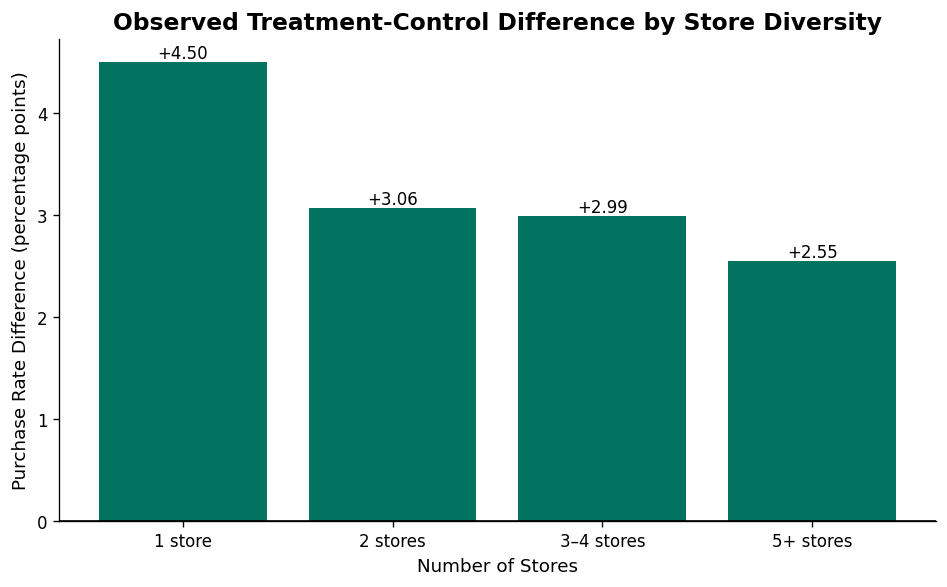

In [613]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    store_diversity_result.index.astype(str),
    store_diversity_result["observed_difference_pp"],
    color=COLORS["pacific_green"],
)

ax.axhline(
    0,
    color="black",
    linewidth=1,
)

ax.set_title(
    "Observed Treatment-Control Difference by Store Diversity"
)
ax.set_xlabel("Number of Stores")
ax.set_ylabel(
    "Purchase Rate Difference (percentage points)"
)

for bar, value in zip(
    bars,
    store_diversity_result["observed_difference_pp"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:+.2f}",
        ha="center",
        va="bottom" if value >= 0 else "top",
    )

plt.tight_layout()
plt.show()

#### Store Diversity Findings

- Customers who shop at more stores have higher purchase rates overall.
- Customers who used only **1 store** had a control purchase rate of **52.00%**, compared with **56.50%** for treatment.
- Purchase rates increased as customers used more stores, reaching **71.55%** for control and **74.10%** for treatment among customers using **5 or more stores**.
- At the same time, the observed treatment-control difference became smaller:
  - **1 store:** +4.50 percentage points;
  - **2 stores:** +3.06 percentage points;
  - **3–4 stores:** +2.99 percentage points;
  - **5+ stores:** +2.55 percentage points.

Customers who shop across more stores are therefore more likely to purchase anyway, while customers tied to fewer stores show a larger observed campaign difference.

This follows the same general pattern seen for frequency, spending, and category diversity.

### Treatment Effect Across Customer Behavior Summary

The EDA shows a consistent difference between customers who were already highly active before the campaign and those with lower prior activity.

Several patterns point in the same direction:

- **Recency:** customers who had not purchased as recently showed a larger treatment-control difference.
- **Frequency:** the difference decreased from about **4.4 percentage points** among lower-frequency customers to about **1.4 points** among the most frequent customers.
- **Spending:** lower-spending customers showed the largest difference (**+5.23 points**), while the highest-spending group showed only about **+1.04 point**.
- **Category diversity:** customers buying across fewer categories showed a larger difference than customers already shopping broadly.
- **Category concentration:** customers whose purchases were more concentrated in one category showed a larger treatment-control difference.
- **Store diversity:** customers shopping at fewer stores showed a larger difference than customers using many stores.

Together, these patterns suggest that customers who are already highly active and broadly engaged with the retailer are very likely to purchase even without treatment.

In contrast, customers with lower or narrower prior activity often have lower baseline purchase rates but a larger observed treatment-control difference.

Not every customer preference shows the same pattern. **Own-brand preference** and **store concentration** do not show a clear directional relationship with campaign response.

These findings provide the main patterns to carry forward into hypothesis checks before feature engineering.